# Dysgraphia Detection with Time-Series Deep Learning (Drotar Dataset)

This notebook implements a **complete, modular pipeline** in **PyTorch** to detect **dysgraphia** from **online handwriting** using the dataset by **Drotár & Dobeš (2020)**.

We will:
- Load and preprocess **raw multivariate time-series** from Wacom tablets (no scalar summaries)
- Engineer **derivative features** (velocity, acceleration, jerk)
- Handle **variable-length sequences** with padding/truncation
- Train and evaluate two models:
  - **1D CNN** with **GlobalAveragePooling1D** (for CAM-style XAI later)
  - **Temporal Convolutional Network (TCN)** with dilated causal convolutions
  - **Hybrid CNN-LSTM**

- Compute **Accuracy, Sensitivity, Specificity, AUC-ROC**, plot **confusion matrix** and **loss curves**

> After this is working, you can plug the trained models into XAI tools such as **TSInterpret** for time-series explanations.


In [ ]:
# --- 1. Imports & Basic Configuration ---

import os
import numpy as np
import pandas as pd
from typing import List, Tuple

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt
from tqdm import tqdm


class Config:
    """Global configuration for this project."""
    # Paths (adapt these when running in Colab or locally)
    DATA_ROOT = "/content/dataSciRep_public"      # folder where you unzip dataSciRep_public.zip
    META_XLSX = "/content/data2_SciRep_pub.xlsx"  # metadata file

    # Time-series handling
    MAX_LEN = 2000            # fixed sequence length (pad/truncate)
    USE_DERIVATIVES = True    # add velocity/acc/jerk channels

    # Training hyperparameters
    BATCH_SIZE = 16
    NUM_EPOCHS = 50
    LR = 1e-3
    WEIGHT_DECAY = 1e-4
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## ADDED THIS
    # Cross-validation / split
    TRAIN_SUBJECT_RATIO = 0.8 # subject-independent train/test split ratio
    NUM_REPEATED_SPLITS = 5   # number of repeated subject-independent splits (outer loop)
                               # Set to 1 for faster execution. Increase to 5 for robust evaluation.
    INNER_CV_FOLDS = 2        # number of folds for inner cross-validation (hyperparameter tuning)
                               # Reduced from 3 to 2 for faster execution

    # Early stopping
    EARLY_STOPPING_PATIENCE = 5  # patience for early stopping (epochs) - reduced for faster training
    EARLY_STOPPING_ENABLED = True

    # Hyperparameter search space (for nested CV)
    # Reduced search space for faster execution
    LR_SEARCH_SPACE = [1e-3]  # learning rates to try (reduced to single value for speed)
    DROPOUT_SEARCH_SPACE = [0.3]  # dropout rates to try (reduced to single value for speed)

##

    # Misc
    RANDOM_STATE = 42


print("Using device:", Config.DEVICE)

Using device: cuda


In [ ]:
# --- 1.1 Unzip raw dataset and set DATA_ROOT (run this once in Colab) ---

import zipfile

# Path where you uploaded the ZIP in Colab
zip_path = "/content/dataSciRep_public.zip"  # change this if your ZIP is elsewhere

# Folder where we will extract the ZIP
extract_dir = "/content/dataSciRep_public"

# Unzip only if not already extracted
if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_dir)
    print("Extracted to:", extract_dir)
else:
    print("Already extracted at:", extract_dir)

# Update Config.DATA_ROOT for this session
Config.DATA_ROOT = extract_dir
print("Config.DATA_ROOT set to:", Config.DATA_ROOT)

Already extracted at: /content/dataSciRep_public
Config.DATA_ROOT set to: /content/dataSciRep_public


## 2. Inspect Metadata and Raw Files

Run the next cell after you have uploaded/unzipped:
- `data2_SciRep_pub.xlsx`
- `dataSciRep_public.zip` (unzipped into `dataSciRep_public`)

This will print metadata columns and show a few raw time-series files so you can quickly verify paths and names.

In [ ]:
# --- 2.1 Inspect metadata and raw file structure ---

# You can adjust Config.META_XLSX and Config.DATA_ROOT above if needed.

if os.path.exists(Config.META_XLSX):
    df_meta_preview = pd.read_excel(Config.META_XLSX)
    print("Metadata columns:", df_meta_preview.columns.tolist())
    print("\nFirst 5 rows of metadata:")
    print(df_meta_preview.head())
else:
    print("Metadata file not found at:", Config.META_XLSX)

print("\nListing a few files under DATA_ROOT:")
if os.path.exists(Config.DATA_ROOT):
    for root, dirs, files in os.walk(Config.DATA_ROOT):
        print("Directory:", root)
        for f in files[:10]:
            print("  ", f)
        break
else:
    print("DATA_ROOT not found:", Config.DATA_ROOT)

Metadata columns: ['ID', 'diag', 'sex', 'hand', 'age', 'Unnamed: 5', 'Unnamed: 6']

First 5 rows of metadata:
   ID   diag sex hand  age  Unnamed: 5 Unnamed: 6
0   6  DYSGR   F    R   15         NaN        NaN
1   7  DYSGR  M     R   15         NaN        NaN
2   8  DYSGR  M     R   14         NaN        NaN
3  11  DYSGR  M     R    8         NaN        NaN
4  13  DYSGR  M     R   14         NaN        NaN

Listing a few files under DATA_ROOT:
Directory: /content/dataSciRep_public


## 3. Data Loading, Derivatives, Normalization, and Padding

The next cells define:
- `load_metadata`: map Excel columns to `file_name`, `subject_id`, `label`.
- `load_raw_timeseries`: parse one handwriting file (x, y, t, pressure, etc.).
- `compute_derivatives`: velocity, acceleration, jerk from x, y, t.
- `pad_truncate` and `StandardScaler` utilities.

You may need to **adapt column names** in `load_metadata` and possibly adjust the file extensions if they differ in your copy of the dataset.

In [ ]:
import re
# --- 3.1 Metadata loader ---

def load_metadata(meta_path: str) -> pd.DataFrame:
    """Load metadata and standardize key columns.

    You MUST adapt the column mapping below to match your Excel file.
    Target columns in the returned DataFrame:
      - file_name : name of the raw time-series file (without or with extension)
      - subject_id: subject identifier (string or int)
      - label     : 0 (non-dysgraphic) or 1 (dysgraphic)
    """
    df = pd.read_excel(meta_path)

    # Map Excel columns to standardized column names
    # Based on data2_SciRep_pub.xlsx structure:
    # - 'ID' column contains subject identifiers
    # - 'diag' column contains diagnosis ('DYSGR' for dysgraphic, others for non-dysgraphic)
    # - 'file_name' is set to subject_id as placeholder (actual files are discovered in section 7.1)

    df['subject_id'] = df['ID'].astype(int)
    df['label'] = (df['diag'].astype(str).str.upper() == 'DYSGR').astype(int)
    df['file_name'] = df['subject_id'].astype(str)  # Placeholder - actual file discovery happens later

    # Return only the required columns
    required_cols = ['file_name', 'subject_id', 'label']
    return df[required_cols].copy()


# --- 3.2 Raw file loader ---
def load_raw_timeseries(filepath: str) -> np.ndarray:
    """Load a single handwriting sample from an .svc/.txt-like file.

    Expected columns (you may adjust this if necessary):
      x, y, t, pressure, azimuth, altitude, pen_status

    Returns:
        np.ndarray of shape (T, C)
    """
    data = []
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("#"):
                continue  # skip comment/header lines
            parts = line.split()
            try:
                row = [float(v) for v in parts]
                data.append(row)
            except ValueError:
                # Skip non-numeric lines
                continue

    if len(data) == 0:
        raise ValueError(f"No numeric data found in file: {filepath}")

    # Some files may have lines with different numbers of columns.
    # Keep only rows with the most frequent length to get a clean (T, C) array.
    lengths = [len(r) for r in data]
    uniq, counts = np.unique(lengths, return_counts=True)
    target_len = int(uniq[np.argmax(counts)])
    filtered = [r for r in data if len(r) == target_len]

    if len(filtered) == 0:
        raise ValueError(
            f"All rows in {filepath} had inconsistent lengths; "
            f"original lengths: {dict(zip(uniq.tolist(), counts.tolist()))}"
        )

    arr = np.array(filtered, dtype=np.float32)

    # Ensure a consistent number of base channels for all samples.
    # The problem description and common practice for this dataset implies 7 core features:
    # x, y, t, pressure, azimuth, altitude, pen_status.
    # This standardization prevents channel mismatch errors if raw files vary.
    EXPECTED_BASE_CHANNELS = 7
    current_channels = arr.shape[1]

    if current_channels > EXPECTED_BASE_CHANNELS:
        # Truncate if there are more channels than expected
        arr = arr[:, :EXPECTED_BASE_CHANNELS]
    elif current_channels < EXPECTED_BASE_CHANNELS:
        # If there are fewer channels than expected, pad with zeros.
        # Files with less than 3 channels are typically filtered out earlier.
        # This ensures 'compute_derivatives' has enough columns (x,y,t) and the model has consistent input.
        padding_needed = EXPECTED_BASE_CHANNELS - current_channels
        arr = np.pad(arr, ((0, 0), (0, padding_needed)), 'constant', constant_values=0)

    return arr  # shape (T, EXPECTED_BASE_CHANNELS)

# --- 3.3 Derivative features (velocity, acceleration, jerk) ---

def compute_derivatives(sample: np.ndarray, x_idx=0, y_idx=1, t_idx=2) -> np.ndarray:
    """Append velocity, acceleration, and jerk for x and y coordinates.

    sample: (T, C) with at least x, y, t at indices x_idx, y_idx, t_idx.
    Returns: (T, C + 6) with [vx, vy, ax, ay, jx, jy] appended.
    """
    T, C = sample.shape # Get sequence length T
    if max(x_idx, y_idx, t_idx) >= C:
        raise ValueError(f"Not enough channels ({C}) to compute derivatives; expected at least 3.")

    # Handle short sequences (length < 2) where derivatives cannot be computed
    if T < 2:
        # Return zeros for derivatives, maintaining original shape
        zero_derivs = np.zeros((T, 6), dtype=np.float32)
        augmented = np.concatenate([sample, zero_derivs], axis=-1)
        return augmented

    x = sample[:, x_idx]
    y = sample[:, y_idx]
    t = sample[:, t_idx]

    dt = np.diff(t)
    dt[dt == 0] = 1e-6  # avoid division by zero

    # Velocity
    vx = np.diff(x) / dt
    vy = np.diff(y) / dt
    vx = np.concatenate([[vx[0]], vx])
    vy = np.concatenate([[vy[0]], vy])

    # Acceleration
    ax = np.diff(vx) / dt
    ay = np.diff(vy) / dt
    ax = np.concatenate([[ax[0]], ax])
    ay = np.concatenate([[ay[0]], ay])

    # Jerk
    jx = np.diff(ax) / dt
    jy = np.diff(ay) / dt
    jx = np.concatenate([[jx[0]], jx])
    jy = np.concatenate([[jy[0]], jy])

    derivs = np.stack([vx, vy, ax, ay, jx, jy], axis=-1)  # (T, 6)
    augmented = np.concatenate([sample, derivs], axis=-1)
    return augmented


# --- 3.4 Padding / truncation ---

def pad_truncate(ts: np.ndarray, max_len: int) -> Tuple[np.ndarray, int]:
    """Pad or truncate a time series to fixed length max_len.

    Args:
        ts: np.ndarray (T, C)
    Returns:
        padded: (max_len, C)
        length: original length (clipped to max_len)
    """
    T, C = ts.shape
    length = min(T, max_len)
    padded = np.zeros((max_len, C), dtype=np.float32)
    padded[:length] = ts[:length]
    return padded, length


# --- 3.5 StandardScaler utilities ---

def fit_scaler_on_train(X_list: List[np.ndarray]) -> StandardScaler:
    """Fit StandardScaler across all time points in all training samples."""
    concat = np.concatenate(X_list, axis=0)  # (sum_T, C)
    scaler = StandardScaler()
    scaler.fit(concat)
    return scaler


def apply_scaler(X: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Apply a fitted scaler to a single time-series sample (T, C)."""
    T, C = X.shape
    X_2d = X.reshape(-1, C)
    X_scaled = scaler.transform(X_2d)
    return X_scaled.reshape(T, C)

## 4. Dataset Class and Subject-Wise Splits

We now define:
- `HandwritingDataset`: wraps the time-series + label into a PyTorch `Dataset` with padding and normalization.
- `subject_independent_split`: ensure train/test subjects don’t overlap.

In [ ]:
# --- 4.1 PyTorch Dataset ---

class HandwritingDataset(Dataset):
    def __init__(self, meta_df: pd.DataFrame, data_root: str, scaler: StandardScaler,
                 max_len: int, use_derivatives: bool = True):
        """Dataset wrapping a set of handwriting trials.

        meta_df: must contain columns ['file_name', 'subject_id', 'label'].
        """
        self.meta_df = meta_df.reset_index(drop=True)
        self.data_root = data_root
        self.max_len = max_len
        self.use_derivatives = use_derivatives
        self.scaler = scaler

    def __len__(self):
        return len(self.meta_df)

    def __getitem__(self, idx):
        row = self.meta_df.iloc[idx]
        file_name = row['file_name']
        label = int(row['label'])
        subject_id = row['subject_id']

        # Try a few possible file name patterns (adapt if needed)
        candidates = [
            os.path.join(self.data_root, f"{file_name}.svc"),
            os.path.join(self.data_root, f"{file_name}.txt"),
            os.path.join(self.data_root, str(file_name)),
        ]
        filepath = None
        for cp in candidates:
            if os.path.exists(cp):
                filepath = cp
                break
        if filepath is None:
            raise FileNotFoundError(f"Could not find raw file for sample '{file_name}'")

        ts = load_raw_timeseries(filepath)  # (T, C)
        if self.use_derivatives:
            ts = compute_derivatives(ts)

        ts = apply_scaler(ts, self.scaler)
        ts_padded, length = pad_truncate(ts, self.max_len)  # (max_len, C)

        # For Conv1d we use (channels, time)
        ts_padded = ts_padded.T  # (C, T)

        return {
            "x": torch.tensor(ts_padded, dtype=torch.float32),
            "y": torch.tensor(label, dtype=torch.long),
            "length": torch.tensor(length, dtype=torch.long),
            "subject_id": subject_id,
        }


# --- 4.2 Subject-wise splits ---

def subject_independent_split(meta_df: pd.DataFrame, train_ratio: float = 0.8,
                              random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Split by subject IDs so that train and test sets do not share subjects."""
    subjects = meta_df['subject_id'].unique()
    rng = np.random.default_rng(random_state)
    rng.shuffle(subjects)

    n_train = int(len(subjects) * train_ratio)
    train_subjects = set(subjects[:n_train])
    test_subjects = set(subjects[n_train:])

    train_df = meta_df[meta_df['subject_id'].isin(train_subjects)].copy()
    test_df = meta_df[meta_df['subject_id'].isin(test_subjects)].copy()
    return train_df, test_df


## 5. Models: 1D CNN, Temporal Convolutional Network (TCN), and Hybrid CNN-LSTM

We define:
- `MaskedGlobalAvgPool1d` to pool over time while respecting true sequence lengths (masks padding).
- `CNN1DModel`: Conv1d + BatchNorm + ReLU + MaxPool, ending with global average pooling for CAM-style XAI.
- `TemporalBlock` and `TCNModel`: dilated causal convolutions with residual connections.

In [ ]:

# --- 5.1 Masked Global Average Pooling ---

class MaskedGlobalAvgPool1d(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x, lengths=None):
        """x: (B, C, T), lengths: (B,) with true lengths.
        If lengths is None, falls back to simple mean over time.
        """
        if lengths is None:
            return x.mean(dim=-1)

        B, C, T = x.shape
        device = x.device
        mask = (torch.arange(T, device=device).unsqueeze(0) < lengths.unsqueeze(1))
        mask = mask.unsqueeze(1)  # (B, 1, T)

        x_masked = x * mask
        lengths_clamped = lengths.clamp(min=1).view(B, 1).float()
        pooled = x_masked.sum(dim=-1) / lengths_clamped
        return pooled


# --- 5.2 1D CNN model ---

class CNN1DModel(nn.Module):
    def __init__(self, in_channels: int, num_classes: int = 2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )

        self.gap = MaskedGlobalAvgPool1d()
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x, lengths=None):
        # x: (B, C, T)
        feat_maps = self.features(x)  # (B, 256, T')

        # Adjust lengths for downsampling by 3 max-pools (factor 2 each)
        if lengths is not None:
            for _ in range(3):
                lengths = (lengths // 2).clamp(min=1)

        pooled = self.gap(feat_maps, lengths)  # (B, 256)
        logits = self.classifier(pooled)       # (B, num_classes)
        return logits, feat_maps


# --- 5.3 TCN blocks and model ---

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.downsample = nn.Conv1d(in_channels, out_channels, kernel_size=1) \
            if in_channels != out_channels else None
        self.final_relu = nn.ReLU()

        self.kernel_size = kernel_size
        self.dilation = dilation

    def forward(self, x):
        # x: (B, C, T)
        out = self.conv1(x)
        cut = (self.kernel_size - 1) * self.dilation
        if cut > 0:
            out = out[:, :, :-cut]
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.dropout1(out)

        out2 = self.conv2(out)
        if cut > 0:
            out2 = out2[:, :, :-cut]
        out2 = self.bn2(out2)
        out2 = self.relu2(out2)
        out2 = self.dropout2(out2)

        res = x if self.downsample is None else self.downsample(x)
        res = res[:, :, -out2.shape[-1]:]

        return self.final_relu(out2 + res)


class TCNModel(nn.Module):
    def __init__(self, in_channels: int, num_classes: int = 2,
                 num_levels: int = 5, kernel_size: int = 3,
                 hidden_channels: int = 64, dropout: float = 0.2):
        super().__init__()

        layers = []
        for i in range(num_levels):
            dilation = 2 ** i
            in_ch = in_channels if i == 0 else hidden_channels
            out_ch = hidden_channels
            layers.append(TemporalBlock(in_ch, out_ch, kernel_size,
                                        dilation=dilation, dropout=dropout))

        self.tcn = nn.Sequential(*layers)
        self.gap = MaskedGlobalAvgPool1d()
        self.classifier = nn.Linear(hidden_channels, num_classes)

    def forward(self, x, lengths=None):
        out = self.tcn(x)              # (B, hidden_channels, T')
        pooled = self.gap(out, lengths)  # lengths unchanged approx.
        logits = self.classifier(pooled)
        return logits, out


# --- 5.4 Hybrid CNN-LSTM model (inspired by Masood et al., 2023) ---

class CNNLSTMModel(nn.Module):
    """
    Hybrid CNN-LSTM model for dysgraphia detection.

    Architecture:
    1. CNN block extracts local spatial/temporal features
    2. LSTM processes the CNN features as a sequence for long-term temporal patterns
    3. Classification head for final prediction

    This combines the local feature extraction capability of CNNs with the
    sequential modeling power of LSTMs, as recommended in recent time-series
    classification literature.
    """
    def __init__(self, in_channels: int, num_classes: int = 2,
                 lstm_hidden_size: int = 64, lstm_layers: int = 2, dropout: float = 0.3):
        super().__init__()

        # 1. CNN Block for Feature Extraction (Spatial/Local patterns)
        # Similar structure to CNN1DModel but fewer layers (LSTM will handle temporal modeling)
        self.cnn_extractor = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        # After 2 MaxPool operations, sequence length is divided by 4

        # 2. LSTM Block for Temporal Evolution (Sequence patterns)
        # Bidirectional LSTM to capture both forward and backward temporal dependencies
        self.lstm = nn.LSTM(
            input_size=128,  # Output channels from CNN
            hidden_size=lstm_hidden_size,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0
        )

        # 3. Classification head
        # *2 for bidirectional (forward + backward hidden states)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(lstm_hidden_size * 2, num_classes)

    def forward(self, x, lengths=None):
        """
        Forward pass through CNN-LSTM hybrid model.

        Args:
            x: Input tensor of shape (B, C, T)
            lengths: Optional tensor of shape (B,) with true sequence lengths

        Returns:
            logits: Classification logits of shape (B, num_classes)
            features: CNN feature maps of shape (B, 128, T/4) for XAI analysis
        """
        # 1. Extract local features with CNN
        features = self.cnn_extractor(x)  # Output: (B, 128, T/4)

        # 2. Prepare for LSTM (permute to B, T, C format for batch_first=True)
        features_seq = features.permute(0, 2, 1)  # (B, T/4, 128)

        # 3. LSTM processing
        lstm_out, (h_n, c_n) = self.lstm(features_seq)

        # 4. Global Pooling: Take the concatenation of the final forward and backward hidden states
        hidden = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1)  # (B, hidden_size*2)

        # 5. Classification
        out = self.dropout(hidden)
        logits = self.classifier(out)

        return logits, features

In [ ]:

# --- 5.4 Hybrid CNN-LSTM model (inspired by Masood et al., 2023) ---

class CNNLSTMModel(nn.Module):
    """
    Hybrid CNN-LSTM model for dysgraphia detection.

    Architecture:
    1. CNN block extracts local spatial/temporal features
    2. LSTM processes the CNN features as a sequence for long-term temporal patterns
    3. Classification head for final prediction

    This combines the local feature extraction capability of CNNs with the
    sequential modeling power of LSTMs, as recommended in recent time-series
    classification literature.
    """
    def __init__(self, in_channels: int, num_classes: int = 2,
                 lstm_hidden_size: int = 64, lstm_layers: int = 2, dropout: float = 0.3):
        super().__init__()

        # 1. CNN Block for Feature Extraction (Spatial/Local patterns)
        # Similar structure to CNN1DModel but fewer layers (LSTM will handle temporal modeling)
        self.cnn_extractor = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        # After 2 MaxPool operations, sequence length is divided by 4

        # 2. LSTM Block for Temporal Evolution (Sequence patterns)
        # Bidirectional LSTM to capture both forward and backward temporal dependencies
        self.lstm = nn.LSTM(
            input_size=128,  # Output channels from CNN
            hidden_size=lstm_hidden_size,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0
        )

        # 3. Classification head
        # *2 for bidirectional (forward + backward hidden states)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(lstm_hidden_size * 2, num_classes)

    def forward(self, x, lengths=None):
        """
        Forward pass through CNN-LSTM hybrid model.

        Args:
            x: Input tensor of shape (B, C, T)
            lengths: Optional tensor of shape (B,) with true sequence lengths

        Returns:
            logits: Classification logits of shape (B, num_classes)
            features: CNN feature maps of shape (B, 128, T/4) for XAI analysis
        """
        # 1. Extract local features with CNN
        features = self.cnn_extractor(x)  # Output: (B, 128, T/4)

        # 2. Prepare for LSTM (permute to B, T, C format for batch_first=True)
        features_seq = features.permute(0, 2, 1)  # (B, T/4, 128)

        # 3. LSTM processing
        lstm_out, (h_n, c_n) = self.lstm(features_seq)

        # 4. Global Pooling: Take the concatenation of the final forward and backward hidden states
        hidden = torch.cat((h_n[-2, :, :], h_n[-1, :, :]), dim=1)  # (B, hidden_size*2)

        # 5. Classification
        out = self.dropout(hidden)
        logits = self.classifier(out)

        return logits, features

## 6. Training, Metrics, and Visualization

We now add:
- `compute_metrics`: accuracy, sensitivity, specificity, AUC.
- `train_one_model`: generic training loop with class weights and ReduceLROnPlateau.
- Plotting helpers for loss curves and confusion matrices.

In [ ]:
# --- 6.1 Metrics ---

from sklearn.metrics import roc_curve


def compute_metrics(y_true, y_pred_probs):
    """Compute accuracy, sensitivity, specificity, AUC and confusion matrix.

    y_true: (N,) ground truth labels (0 or 1)
    y_pred_probs: (N,) predicted probability for class 1
    """
    y_true = np.asarray(y_true)
    y_pred_probs = np.asarray(y_pred_probs)
    y_pred = (y_pred_probs >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)

    try:
        auc = roc_auc_score(y_true, y_pred_probs)
    except ValueError:
        auc = np.nan

    return {
        "accuracy": acc,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "auc": auc,
        "confusion_matrix": cm,
    }


# --- 6.2 Training loop with Early Stopping ---

def train_one_model(train_loader: DataLoader,
                    val_loader: DataLoader,
                    model: nn.Module,
                    num_epochs: int,
                    class_weights: np.ndarray,
                    lr: float,
                    weight_decay: float,
                    device: str = "cuda",
                    early_stopping_patience: int = 7,
                    early_stopping_enabled: bool = True):
    """
    Train a model with early stopping mechanism.

    Args:
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        model: PyTorch model to train
        num_epochs: Maximum number of epochs
        class_weights: Class weights for imbalanced data
        lr: Learning rate
        weight_decay: Weight decay for optimizer
        device: Device to train on
        early_stopping_patience: Number of epochs to wait before early stopping
        early_stopping_enabled: Whether to enable early stopping

    Returns:
        model: Trained model (with best weights restored)
        history: Training history dictionary
    """
    model.to(device)

    weight_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)

    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    history = {"train_loss": [], "val_loss": [], "val_metrics": []}

    # Early stopping variables
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    best_epoch = 0

    for epoch in range(num_epochs):
        model.train()
        train_losses = []

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False):
            x = batch["x"].to(device)
            y = batch["y"].to(device)
            lengths = batch["length"].to(device)

            optimizer.zero_grad()
            logits, _ = model(x, lengths)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        avg_train_loss = float(np.mean(train_losses)) if train_losses else 0.0

        # Validation
        model.eval()
        val_losses = []
        all_probs, all_labels = [], []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False):
                x = batch["x"].to(device)
                y = batch["y"].to(device)
                lengths = batch["length"].to(device)

                logits, _ = model(x, lengths)
                loss = criterion(logits, y)
                val_losses.append(loss.item())

                probs = torch.softmax(logits, dim=1)[:, 1]
                all_probs.append(probs.cpu().numpy())
                all_labels.append(y.cpu().numpy())

        avg_val_loss = float(np.mean(val_losses)) if val_losses else 0.0
        all_probs = np.concatenate(all_probs) if all_probs else np.array([])
        all_labels = np.concatenate(all_labels) if all_labels else np.array([])

        if all_labels.size > 0:
            metrics = compute_metrics(all_labels, all_probs)
        else:
            metrics = {"accuracy": np.nan, "sensitivity": np.nan,
                       "specificity": np.nan, "auc": np.nan,
                       "confusion_matrix": np.array([[0, 0], [0, 0]])}

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_metrics"].append(metrics)

        # Early stopping logic: save best model and check patience
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1
            patience_counter = 0
            # Save the best model state
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        print(
            f"Epoch {epoch+1}/{num_epochs} - "
            f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, "
            f"Acc: {metrics['accuracy']:.4f}, "
            f"Sens: {metrics['sensitivity']:.4f}, "
            f"Spec: {metrics['specificity']:.4f}, "
            f"AUC: {metrics['auc']:.4f}"
        )
        if early_stopping_enabled:
            print(f"  Best Val Loss: {best_val_loss:.4f} (Epoch {best_epoch}), Patience: {patience_counter}/{early_stopping_patience}")

        scheduler.step(avg_val_loss)

        # Early stopping check
        if early_stopping_enabled and patience_counter >= early_stopping_patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}. Best model was at epoch {best_epoch}.")
            break

    # Restore best model weights
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Restored model weights from epoch {best_epoch} (best validation loss: {best_val_loss:.4f})")
    else:
        print("Warning: No best model state saved. Using final epoch weights.")

    return model, history


# --- 6.3 Plot helpers ---

def plot_loss_curves(history, title_prefix=""):
    train_loss = history["train_loss"]
    val_loss = history["val_loss"]

    plt.figure(figsize=(6, 4))
    plt.plot(train_loss, label="Train Loss")
    plt.plot(val_loss, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_confusion_matrix(cm, class_names=("Non-dysgraphic", "Dysgraphic"), title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(4, 4))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel='True label',
        xlabel='Predicted label',
        title=title,
    )

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    fmt = "d"
    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], fmt),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
            )

    fig.tight_layout()
    plt.show()


# --- 6.4 Helper functions for Nested Cross-Validation ---

def create_inner_cv_splits(meta_df: pd.DataFrame, n_folds: int = 3, random_state: int = 42):
    """
    Create subject-independent folds for inner cross-validation.

    Args:
        meta_df: DataFrame with columns ['subject_id', 'label', 'file_name']
        n_folds: Number of folds
        random_state: Random seed

    Returns:
        List of (train_df, val_df) tuples
    """
    subjects = meta_df['subject_id'].unique()
    rng = np.random.default_rng(random_state)
    rng.shuffle(subjects)

    # Split subjects into n_folds
    fold_size = len(subjects) // n_folds
    folds = []

    for i in range(n_folds):
        start_idx = i * fold_size
        end_idx = (i + 1) * fold_size if i < n_folds - 1 else len(subjects)
        val_subjects = set(subjects[start_idx:end_idx])
        train_subjects = set(subjects) - val_subjects

        train_df = meta_df[meta_df['subject_id'].isin(train_subjects)].copy()
        val_df = meta_df[meta_df['subject_id'].isin(val_subjects)].copy()
        folds.append((train_df, val_df))

    return folds


def hyperparameter_search(model_class, model_kwargs, train_meta: pd.DataFrame,
                         data_root: str, max_len: int, use_derivatives: bool,
                         lr_space: List[float], dropout_space: List[float],
                         num_epochs: int, batch_size: int, device: str,
                         n_inner_folds: int = 3, random_state: int = 42):
    """
    Perform grid search for hyperparameters using nested cross-validation.

    Args:
        model_class: Model class (e.g., CNN1DModel, CNNLSTMModel)
        model_kwargs: Dictionary of model initialization arguments (excluding dropout)
        train_meta: Training metadata DataFrame
        data_root: Root directory for data files
        max_len: Maximum sequence length
        use_derivatives: Whether to use derivative features
        lr_space: List of learning rates to try
        dropout_space: List of dropout rates to try
        num_epochs: Number of training epochs
        batch_size: Batch size
        device: Device to train on
        n_inner_folds: Number of inner CV folds
        random_state: Random seed

    Returns:
        Dictionary with best hyperparameters and their validation score
    """
    print(f"\n=== Hyperparameter Search (Inner CV: {n_inner_folds} folds) ===")

    # Create inner CV splits
    inner_folds = create_inner_cv_splits(train_meta, n_folds=n_inner_folds, random_state=random_state)

    best_score = -np.inf
    best_params = None
    all_results = []

    # Grid search over hyperparameters
    for lr in lr_space:
        for dropout in dropout_space:
            print(f"\n  Testing LR={lr:.0e}, Dropout={dropout:.2f}")

            fold_scores = []

            for fold_idx, (inner_train_df, inner_val_df) in enumerate(inner_folds):
                # Fit scaler on inner training fold
                inner_train_raw = []
                for _, row in inner_train_df.iterrows():
                    filepath = os.path.join(data_root, row['file_name'])
                    if not os.path.exists(filepath):
                        continue
                    ts = load_raw_timeseries(filepath)
                    if use_derivatives:
                        ts = compute_derivatives(ts)
                    inner_train_raw.append(ts)

                if not inner_train_raw:
                    continue

                inner_scaler = fit_scaler_on_train(inner_train_raw)

                # Build datasets
                inner_train_dataset = HandwritingDataset(
                    inner_train_df, data_root=data_root, scaler=inner_scaler,
                    max_len=max_len, use_derivatives=use_derivatives
                )
                inner_val_dataset = HandwritingDataset(
                    inner_val_df, data_root=data_root, scaler=inner_scaler,
                    max_len=max_len, use_derivatives=use_derivatives
                )

                inner_train_loader = DataLoader(
                    inner_train_dataset, batch_size=batch_size, shuffle=True,
                    num_workers=2, pin_memory=True
                )
                inner_val_loader = DataLoader(
                    inner_val_dataset, batch_size=batch_size, shuffle=False,
                    num_workers=2, pin_memory=True
                )

                # Get input channels
                sample = inner_train_dataset[0]['x']
                in_channels = sample.shape[0]

                # Create model with current hyperparameters
                model_kwargs_copy = model_kwargs.copy()
                model_kwargs_copy['in_channels'] = in_channels

                # Add dropout if model supports it
                if 'dropout' in model_kwargs_copy:
                    model_kwargs_copy['dropout'] = dropout
                elif model_class == CNNLSTMModel:
                    model_kwargs_copy['dropout'] = dropout

                model = model_class(**model_kwargs_copy)

                # Class weights
                y_inner_train = inner_train_df['label'].values
                classes = np.array([0, 1])
                class_weights = compute_class_weight(
                    class_weight='balanced', classes=classes, y=y_inner_train
                )

                # Train with early stopping
                model, _ = train_one_model(
                    train_loader=inner_train_loader,
                    val_loader=inner_val_loader,
                    model=model,
                    num_epochs=num_epochs,
                    class_weights=class_weights,
                    lr=lr,
                    weight_decay=Config.WEIGHT_DECAY,
                    device=device,
                    early_stopping_patience=Config.EARLY_STOPPING_PATIENCE,
                    early_stopping_enabled=Config.EARLY_STOPPING_ENABLED,
                )

                # Evaluate on inner validation set
                model.eval()
                all_probs, all_labels = [], []
                with torch.no_grad():
                    for batch in inner_val_loader:
                        x = batch['x'].to(device)
                        y = batch['y'].to(device)
                        lengths = batch['length'].to(device)
                        logits, _ = model(x, lengths)
                        probs = torch.softmax(logits, dim=1)[:, 1]
                        all_probs.append(probs.cpu().numpy())
                        all_labels.append(y.cpu().numpy())

                all_probs = np.concatenate(all_probs)
                all_labels = np.concatenate(all_labels)
                metrics = compute_metrics(all_labels, all_probs)

                # Use AUC as the score (or accuracy if AUC is NaN)
                score = metrics['auc'] if not np.isnan(metrics['auc']) else metrics['accuracy']
                fold_scores.append(score)

            # Average score across inner folds
            if fold_scores:
                avg_score = np.mean(fold_scores)
                all_results.append({
                    'lr': lr,
                    'dropout': dropout,
                    'score': avg_score,
                    'std': np.std(fold_scores)
                })
                print(f"    Average CV Score: {avg_score:.4f} (+/- {np.std(fold_scores):.4f})")

                if avg_score > best_score:
                    best_score = avg_score
                    best_params = {'lr': lr, 'dropout': dropout}

    print(f"\n  Best hyperparameters: LR={best_params['lr']:.0e}, Dropout={best_params['dropout']:.2f} (Score: {best_score:.4f})")

    return best_params, all_results

## 7. Repeated Subject-Independent Splits with Nested Cross-Validation

This section implements:
- **Repeated Subject-Independent Splits**: 5 different 80-20 train-test splits with different random seeds
- **Nested Cross-Validation**: Inner loop (3-fold CV) for hyperparameter tuning (Learning Rate and Dropout)
- **Early Stopping**: Automatically restores best model weights during training
- **Aggregated Results**: Mean and standard deviation of metrics across 5 runs

The pipeline ensures:
- No subject leakage (all samples from the same subject stay in the same split)
- Proper hyperparameter tuning using only training data
- Robust performance estimates across multiple random splits

In [ ]:
import re
# --- 7.1 Prepare metadata and discover file paths ---

# 1. Load and map subject-level metadata
raw_meta = pd.read_excel(Config.META_XLSX)

subject_meta = pd.DataFrame()
subject_meta['subject_id'] = raw_meta['ID'].astype(int)
subject_meta['label'] = (raw_meta['diag'].astype(str).str.upper() == 'DYSGR').astype(int)

print("Subject-level metadata (first 5 rows):")
print(subject_meta.head())

# 2. Discover all .svc/.txt files under DATA_ROOT and map them to subject IDs
file_records = []
subject_ids = set(subject_meta['subject_id'].tolist())

for root, dirs, files in os.walk(Config.DATA_ROOT):
    for fname in files:
        if not fname.lower().endswith(('.svc', '.txt')):
            continue
        base = os.path.splitext(fname)[0]

        # Extract all integer substrings from the base filename
        ints_in_name = [int(m.group()) for m in re.finditer(r'\d+', base)]
        if not ints_in_name:
            continue

        for sid in ints_in_name:
            if sid in subject_ids:
                rel_path = os.path.relpath(os.path.join(root, fname), Config.DATA_ROOT)
                file_records.append({
                    'subject_id': sid,
                    'file_name': rel_path,
                })
                break  # stop at first matching subject ID for this file

file_df = pd.DataFrame(file_records)
if file_df.empty:
    raise RuntimeError(f"No .svc/.txt files in {Config.DATA_ROOT} matched any subject IDs from metadata.")

print("\nDiscovered file mappings (first 10 rows):")
print(file_df.head(10))

# 2b. Validate files have enough channels (>= 3) and consistent rows
valid_records = []
for _, row in file_df.iterrows():
    rel = row['file_name']
    full_path = os.path.join(Config.DATA_ROOT, rel)
    try:
        ts = load_raw_timeseries(full_path)
    except Exception as e:
        print(f"Skipping {rel}: {e}")
        continue
    if ts.shape[1] < 3:
        print(f"Skipping {rel}: only {ts.shape[1]} channel(s), need >= 3 for x,y,t.")
        continue
    valid_records.append(row)

file_df = pd.DataFrame(valid_records)
if file_df.empty:
    raise RuntimeError("After validation, no files with >=3 channels remained. Check data format.")

print("\nValidated file mappings (first 10 rows):")
print(file_df.head(10))

# 3. Merge subject labels into file-level metadata
meta_df = file_df.merge(subject_meta, on='subject_id', how='inner')
print("\nFile-level metadata after merge (first 10 rows):")
print(meta_df.head(10))
print(f"\nTotal samples: {len(meta_df)}, Unique subjects: {meta_df['subject_id'].nunique()}")



Subject-level metadata (first 5 rows):
   subject_id  label
0           6      1
1           7      1
2           8      1
3          11      1
4          13      1

Discovered file mappings (first 10 rows):
   subject_id                                          file_name
0           8  dataSciRep_public/user00008/session00001/u0000...
1          58  dataSciRep_public/user00058/session00001/u0005...
2          84  dataSciRep_public/user00084/session00001/u0008...
3         141  dataSciRep_public/user00141/session00001/u0014...
4         100  dataSciRep_public/user00100/session00001/u0010...
5          95  dataSciRep_public/user00095/session00001/u0009...
6          99  dataSciRep_public/user00099/session00001/u0009...
7          49  dataSciRep_public/user00049/session00001/u0004...
8          51  dataSciRep_public/user00051/session00001/u0005...
9         183  dataSciRep_public/user00183/session00001/u0018...

Validated file mappings (first 10 rows):
   subject_id                      

In [ ]:
##ADDED THIS

# --- 7.2 Repeated Subject-Independent Splits: Setup and Initialization ---

# Store results across all runs for all 3 models
all_run_metrics_cnn = []
all_run_metrics_tcn = []
all_run_metrics_cnnlstm = []

# Random seeds for 5 different splits
split_seeds = [42, 123, 456, 789, 1011]

print("=" * 80)
print(f"REPEATED SUBJECT-INDEPENDENT SPLITS: {Config.NUM_REPEATED_SPLITS} runs")
print("=" * 80)
print("\nThis cell initializes the repeated splits loop.")
print("Each run will train and evaluate 3 models: CNN1D, TCN, and CNN-LSTM")
print("Each run will be executed in separate cells below for easier debugging.")

REPEATED SUBJECT-INDEPENDENT SPLITS: 1 runs

This cell initializes the repeated splits loop.
Each run will train and evaluate 3 models: CNN1D, TCN, and CNN-LSTM
Each run will be executed in separate cells below for easier debugging.


In [ ]:
# --- 7.3 AUTOMATED LOOP: All 5 Repeated Splits with Nested CV ---
#
# This cell automatically runs all 5 repeated subject-independent splits.
# For each split:
#   1. Performs hyperparameter tuning (inner CV) for CNN-LSTM
#   2. Trains all 3 models (CNN1D, TCN, CNN-LSTM) with best hyperparameters
#   3. Evaluates on test set
#   4. Stores results (plots suppressed during loop for cleaner output)

import warnings
warnings.filterwarnings('ignore')

# Suppress plots during the loop (we'll show summary at the end)
import matplotlib
matplotlib_backend = matplotlib.get_backend()  # Save current backend
matplotlib.use('Agg')  # Non-interactive backend to suppress plots

print("="*80)
print(f"AUTOMATED EXECUTION: Running {Config.NUM_REPEATED_SPLITS} Repeated Subject-Independent Split(s)")
print("="*80)
print(f"Total runs: {Config.NUM_REPEATED_SPLITS}")
print(f"Inner CV folds: {Config.INNER_CV_FOLDS}")
print(f"Hyperparameter combinations: {len(Config.LR_SEARCH_SPACE)} LR × {len(Config.DROPOUT_SEARCH_SPACE)} Dropout = {len(Config.LR_SEARCH_SPACE) * len(Config.DROPOUT_SEARCH_SPACE)}")
print(f"Each run includes: Hyperparameter tuning + Training 3 models")
print("="*80)
if Config.NUM_REPEATED_SPLITS == 1:
    print("NOTE: Running in FAST MODE (1 split). For robust evaluation, set NUM_REPEATED_SPLITS = 5 in Config.")
    print("="*80)

# Verify that all model classes are defined
required_models = ['CNN1DModel', 'TCNModel', 'CNNLSTMModel']
missing_models = [m for m in required_models if m not in globals()]
if missing_models:
    raise NameError(f"Missing model classes: {missing_models}. Please run cell 10 first!")

# Initialize storage for all runs
if 'all_run_metrics_cnn' not in globals():
    all_run_metrics_cnn = []
if 'all_run_metrics_tcn' not in globals():
    all_run_metrics_tcn = []
if 'all_run_metrics_cnnlstm' not in globals():
    all_run_metrics_cnnlstm = []

# Random seeds for 5 different splits
split_seeds = [42, 123, 456, 789, 1011]

# Format AUC helper
def format_auc(auc_value):
    """Safely format AUC value, handling NaN."""
    return f"{auc_value:.4f}" if not np.isnan(auc_value) else "N/A"

# Main loop: Run all 5 splits
for run_idx in range(Config.NUM_REPEATED_SPLITS):
    seed = split_seeds[run_idx]

    print("\n" + "="*80)
    print(f"OUTER LOOP - Run {run_idx+1}/{Config.NUM_REPEATED_SPLITS} (Random Seed: {seed})")
    print("="*80)

    # ========================================================================
    # STEP 1: Data Preparation and Split
    # ========================================================================
    train_meta, test_meta = subject_independent_split(
        meta_df, train_ratio=Config.TRAIN_SUBJECT_RATIO, random_state=seed
    )

    print(f"Train subjects: {len(set(train_meta['subject_id'].tolist()))}, "
          f"Test subjects: {len(set(test_meta['subject_id'].tolist()))}")
    print(f"Train samples: {len(train_meta)}, Test samples: {len(test_meta)}")

    # Fit scaler on training data
    train_raw_list = []
    for _, row in train_meta.iterrows():
        filepath = os.path.join(Config.DATA_ROOT, row['file_name'])
        if not os.path.exists(filepath):
            continue
        ts = load_raw_timeseries(filepath)
        if Config.USE_DERIVATIVES:
            ts = compute_derivatives(ts)
        train_raw_list.append(ts)

    scaler = fit_scaler_on_train(train_raw_list)

    # Get input channels from the dataset
    temp_dataset = HandwritingDataset(
        train_meta.iloc[:1], data_root=Config.DATA_ROOT, scaler=scaler,
        max_len=Config.MAX_LEN, use_derivatives=Config.USE_DERIVATIVES
    )
    sample_from_dataset = temp_dataset[0]['x']
    in_channels = sample_from_dataset.shape[0]

    # ========================================================================
    # STEP 2: Hyperparameter Tuning (Inner CV) for CNN-LSTM
    # ========================================================================
    # Skip hyperparameter search if only 1 combination (use values directly)
    total_combinations = len(Config.LR_SEARCH_SPACE) * len(Config.DROPOUT_SEARCH_SPACE)

    if total_combinations == 1:
        # Skip CV - just use the single combination
        print("\n" + "-"*80)
        print(f"HYPERPARAMETER TUNING: Skipping CV (only 1 combination) - Run {run_idx+1}")
        print("-"*80)
        best_params = {
            'lr': Config.LR_SEARCH_SPACE[0],
            'dropout': Config.DROPOUT_SEARCH_SPACE[0]
        }
        print(f"Using parameters: LR={best_params['lr']:.0e}, Dropout={best_params['dropout']:.2f}")
    else:
        # Perform full hyperparameter search
        print("\n" + "-"*80)
        print(f"INNER LOOP: Hyperparameter Tuning ({Config.INNER_CV_FOLDS}-fold CV) - Run {run_idx+1}")
        print("-"*80)

        best_params, hp_results = hyperparameter_search(
            model_class=CNNLSTMModel,
            model_kwargs={'num_classes': 2, 'lstm_hidden_size': 64, 'lstm_layers': 2},
            train_meta=train_meta,
            data_root=Config.DATA_ROOT,
            max_len=Config.MAX_LEN,
            use_derivatives=Config.USE_DERIVATIVES,
            lr_space=Config.LR_SEARCH_SPACE,
            dropout_space=Config.DROPOUT_SEARCH_SPACE,
            num_epochs=Config.NUM_EPOCHS,
            batch_size=Config.BATCH_SIZE,
            device=Config.DEVICE,
            n_inner_folds=Config.INNER_CV_FOLDS,
            random_state=seed + 1000
        )

        print(f"Best parameters: LR={best_params['lr']:.0e}, Dropout={best_params['dropout']:.2f}")

    # ========================================================================
    # STEP 3: Build Datasets and Loaders
    # ========================================================================
    train_dataset = HandwritingDataset(
        train_meta, data_root=Config.DATA_ROOT, scaler=scaler,
        max_len=Config.MAX_LEN, use_derivatives=Config.USE_DERIVATIVES
    )
    test_dataset = HandwritingDataset(
        test_meta, data_root=Config.DATA_ROOT, scaler=scaler,
        max_len=Config.MAX_LEN, use_derivatives=Config.USE_DERIVATIVES
    )

    train_loader = DataLoader(
        train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True,
        num_workers=2, pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False,
        num_workers=2, pin_memory=True
    )

    # Class weights
    y_train = train_meta['label'].values
    classes = np.array([0, 1])
    class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

    # ========================================================================
    # STEP 4: Train and Evaluate All 3 Models
    # ========================================================================

    # --- MODEL 1: CNN1D ---
    print(f"\n[MODEL 1/3] CNN1D - Run {run_idx+1}/{Config.NUM_REPEATED_SPLITS}")
    cnn_model = CNN1DModel(in_channels=in_channels, num_classes=2)
    cnn_model, cnn_history = train_one_model(
        train_loader=train_loader, val_loader=test_loader, model=cnn_model,
        num_epochs=Config.NUM_EPOCHS, class_weights=class_weights,
        lr=Config.LR, weight_decay=Config.WEIGHT_DECAY, device=Config.DEVICE,
        early_stopping_patience=Config.EARLY_STOPPING_PATIENCE,
        early_stopping_enabled=Config.EARLY_STOPPING_ENABLED,
    )
    cnn_model.eval()
    all_probs_cnn, all_labels_cnn = [], []
    with torch.no_grad():
        for batch in test_loader:
            x = batch['x'].to(Config.DEVICE)
            y = batch['y'].to(Config.DEVICE)
            lengths = batch['length'].to(Config.DEVICE)
            logits, _ = cnn_model(x, lengths)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs_cnn.append(probs.cpu().numpy())
            all_labels_cnn.append(y.cpu().numpy())
    all_probs_cnn = np.concatenate(all_probs_cnn)
    all_labels_cnn = np.concatenate(all_labels_cnn)
    cnn_metrics = compute_metrics(all_labels_cnn, all_probs_cnn)
    all_run_metrics_cnn.append(cnn_metrics)
    print(f"  CNN1D: Acc={cnn_metrics['accuracy']:.4f}, Sens={cnn_metrics['sensitivity']:.4f}, "
          f"Spec={cnn_metrics['specificity']:.4f}, AUC={format_auc(cnn_metrics['auc'])}")

    # --- MODEL 2: TCN ---
    print(f"\n[MODEL 2/3] TCN - Run {run_idx+1}/{Config.NUM_REPEATED_SPLITS}")
    tcn_model = TCNModel(in_channels=in_channels, num_classes=2)
    tcn_model, tcn_history = train_one_model(
        train_loader=train_loader, val_loader=test_loader, model=tcn_model,
        num_epochs=Config.NUM_EPOCHS, class_weights=class_weights,
        lr=Config.LR, weight_decay=Config.WEIGHT_DECAY, device=Config.DEVICE,
        early_stopping_patience=Config.EARLY_STOPPING_PATIENCE,
        early_stopping_enabled=Config.EARLY_STOPPING_ENABLED,
    )
    tcn_model.eval()
    all_probs_tcn, all_labels_tcn = [], []
    with torch.no_grad():
        for batch in test_loader:
            x = batch['x'].to(Config.DEVICE)
            y = batch['y'].to(Config.DEVICE)
            lengths = batch['length'].to(Config.DEVICE)
            logits, _ = tcn_model(x, lengths)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs_tcn.append(probs.cpu().numpy())
            all_labels_tcn.append(y.cpu().numpy())
    all_probs_tcn = np.concatenate(all_probs_tcn)
    all_labels_tcn = np.concatenate(all_labels_tcn)
    tcn_metrics = compute_metrics(all_labels_tcn, all_probs_tcn)
    all_run_metrics_tcn.append(tcn_metrics)
    print(f"  TCN:   Acc={tcn_metrics['accuracy']:.4f}, Sens={tcn_metrics['sensitivity']:.4f}, "
          f"Spec={tcn_metrics['specificity']:.4f}, AUC={format_auc(tcn_metrics['auc'])}")

    # --- MODEL 3: CNN-LSTM ---
    print(f"\n[MODEL 3/3] CNN-LSTM - Run {run_idx+1}/{Config.NUM_REPEATED_SPLITS}")
    cnnlstm_model = CNNLSTMModel(
        in_channels=in_channels, num_classes=2,
        lstm_hidden_size=64, lstm_layers=2, dropout=best_params['dropout']
    )
    cnnlstm_model, cnnlstm_history = train_one_model(
        train_loader=train_loader, val_loader=test_loader, model=cnnlstm_model,
        num_epochs=Config.NUM_EPOCHS, class_weights=class_weights,
        lr=best_params['lr'], weight_decay=Config.WEIGHT_DECAY, device=Config.DEVICE,
        early_stopping_patience=Config.EARLY_STOPPING_PATIENCE,
        early_stopping_enabled=Config.EARLY_STOPPING_ENABLED,
    )
    cnnlstm_model.eval()
    all_probs_cnnlstm, all_labels_cnnlstm = [], []
    with torch.no_grad():
        for batch in test_loader:
            x = batch['x'].to(Config.DEVICE)
            y = batch['y'].to(Config.DEVICE)
            lengths = batch['length'].to(Config.DEVICE)
            logits, _ = cnnlstm_model(x, lengths)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs_cnnlstm.append(probs.cpu().numpy())
            all_labels_cnnlstm.append(y.cpu().numpy())
    all_probs_cnnlstm = np.concatenate(all_probs_cnnlstm)
    all_labels_cnnlstm = np.concatenate(all_labels_cnnlstm)
    cnnlstm_metrics = compute_metrics(all_labels_cnnlstm, all_probs_cnnlstm)
    all_run_metrics_cnnlstm.append(cnnlstm_metrics)
    print(f"  CNN-LSTM: Acc={cnnlstm_metrics['accuracy']:.4f}, Sens={cnnlstm_metrics['sensitivity']:.4f}, "
          f"Spec={cnnlstm_metrics['specificity']:.4f}, AUC={format_auc(cnnlstm_metrics['auc'])}")

    print(f"\n{'='*80}")
    print(f"Run {run_idx+1}/{Config.NUM_REPEATED_SPLITS} completed!")
    print(f"{'='*80}")

# Restore interactive matplotlib backend
try:
    matplotlib.use(matplotlib_backend)
except:
    matplotlib.use('TkAgg')  # Fallback

print("\n" + "="*80)
print(f"ALL {Config.NUM_REPEATED_SPLITS} RUN(S) COMPLETED SUCCESSFULLY!")
print("="*80)
print(f"Total runs completed: {len(all_run_metrics_cnn)}/{Config.NUM_REPEATED_SPLITS}")
if Config.NUM_REPEATED_SPLITS == 1:
    print("\nNOTE: Results are from a single split. For robust evaluation with statistics,")
    print("      set NUM_REPEATED_SPLITS = 5 in Config and re-run this cell.")
print("\nProceed to Cell 19 to view results and visualizations.")
print("="*80)


AUTOMATED EXECUTION: Running 1 Repeated Subject-Independent Split(s)
Total runs: 1
Inner CV folds: 2
Hyperparameter combinations: 1 LR × 1 Dropout = 1
Each run includes: Hyperparameter tuning + Training 3 models
NOTE: Running in FAST MODE (1 split). For robust evaluation, set NUM_REPEATED_SPLITS = 5 in Config.

OUTER LOOP - Run 1/1 (Random Seed: 42)
Train subjects: 96, Test subjects: 24
Train samples: 96, Test samples: 25

--------------------------------------------------------------------------------
HYPERPARAMETER TUNING: Skipping CV (only 1 combination) - Run 1
--------------------------------------------------------------------------------
Using parameters: LR=1e-03, Dropout=0.30

[MODEL 1/3] CNN1D - Run 1/1


Epoch 1/50 - Train Loss: 0.4705, Val Loss: 0.4892, Acc: 0.9200, Sens: 1.0000, Spec: 0.8571, AUC: 0.9610
  Best Val Loss: 0.4892 (Epoch 1), Patience: 0/5


Epoch 2/50 - Train Loss: 0.2884, Val Loss: 0.3662, Acc: 0.8800, Sens: 0.9091, Spec: 0.8571, AUC: 0.9091
  Best Val Loss: 0.3662 (Epoch 2), Patience: 0/5


Epoch 3/50 - Train Loss: 0.2458, Val Loss: 0.5745, Acc: 0.7200, Sens: 0.9091, Spec: 0.5714, AUC: 0.9091
  Best Val Loss: 0.3662 (Epoch 2), Patience: 1/5


Epoch 4/50 - Train Loss: 0.1915, Val Loss: 0.5251, Acc: 0.8000, Sens: 0.9091, Spec: 0.7143, AUC: 0.9091
  Best Val Loss: 0.3662 (Epoch 2), Patience: 2/5


...

Epoch 7/50 - Train Loss: 0.1665, Val Loss: 0.2203, Acc: 0.8800, Sens: 0.9091, Spec: 0.8571, AUC: 0.9675
  Best Val Loss: 0.1954 (Epoch 5), Patience: 2/5


Epoch 8/50 - Train Loss: 0.1949, Val Loss: 0.2253, Acc: 0.8400, Sens: 0.9091, Spec: 0.7857, AUC: 0.9610
  Best Val Loss: 0.1954 (Epoch 5), Patience: 3/5


Epoch 9/50 - Train Loss: 0.1559, Val Loss: 0.2487, Acc: 0.8400, Sens: 1.0000, Spec: 0.7143, AUC: 0.9545
  Best Val Loss: 0.1954 (Epoch 5), Patience: 4/5


Epoch 10/50 - Train Loss: 0.1927, Val Loss: 0.2537, Acc: 0.8400, Sens: 1.0000, Spec: 0.7143, AUC: 0.9805
  Best Val Loss: 0.1954 (Epoch 5), Patience: 5/5

Early stopping triggered at epoch 10. Best model was at epoch 5.
Restored model weights from epoch 5 (best validation loss: 0.1954)


  CNN-LSTM: Acc=0.9200, Sens=0.9091, Spec=0.9286, AUC=0.9740

Run 1/1 completed!

ALL 1 RUN(S) COMPLETED SUCCESSFULLY!
Total runs completed: 1/1

NOTE: Results are from a single split. For robust evaluation with statistics,
      set NUM_REPEATED_SPLITS = 5 in Config and re-run this cell.

Proceed to Cell 19 to view results and visualizations.


NOTE: This cell is deprecated.
Cell 17 now automatically runs all 5 splits.
Please run Cell 17 instead, then proceed to Cell 19 for results.
Using 13 input channels for all models

MODEL 1: CNN1D - Run 1

Creating CNN1D model with:
  in_channels: 13
  learning_rate: 0.001


Epoch 1/50 - Train Loss: 0.5242, Val Loss: 0.6023, Acc: 0.4000, Sens: 0.9091, Spec: 0.0000, AUC: 0.8442
  Best Val Loss: 0.6023 (Epoch 1), Patience: 0/5


Epoch 2/50 - Train Loss: 0.3117, Val Loss: 0.4877, Acc: 0.8000, Sens: 0.9091, Spec: 0.7143, AUC: 0.8961
  Best Val Loss: 0.4877 (Epoch 2), Patience: 0/5


Epoch 3/50 - Train Loss: 0.2252, Val Loss: 0.3877, Acc: 0.8800, Sens: 0.9091, Spec: 0.8571, AUC: 0.9026
  Best Val Loss: 0.3877 (Epoch 3), Patience: 0/5


Epoch 4/50 - Train Loss: 0.2631, Val Loss: 0.4985, Acc: 0.8000, Sens: 0.9091, Spec: 0.7143, AUC: 0.8961
  Best Val Loss: 0.3877 (Epoch 3), Patience: 1/5


Epoch 5/50 - Train Loss: 0.2367, Val Loss: 0.4279, Acc: 0.8800, Sens: 0.9091, Spec: 0.8571, AUC: 0.9091
  Best Val Loss: 0.3877 (Epoch 3), Patience: 2/5


Epoch 6/50 - Train Loss: 0.2031, Val Loss: 0.5130, Acc: 0.8800, Sens: 0.9091, Spec: 0.8571, AUC: 0.9091
  Best Val Loss: 0.3877 (Epoch 3), Patience: 3/5


Epoch 7/50 - Train Loss: 0.2014, Val Loss: 0.6052, Acc: 0.8400, Sens: 0.9091, Spec: 0.7857, AUC: 0.9091
  Best Val Loss: 0.3877 (Epoch 3), Patience: 4/5


Epoch 8/50 - Train Loss: 0.1577, Val Loss: 0.7175, Acc: 0.8400, Sens: 0.9091, Spec: 0.7857, AUC: 0.9091
  Best Val Loss: 0.3877 (Epoch 3), Patience: 5/5

Early stopping triggered at epoch 8. Best model was at epoch 3.
Restored model weights from epoch 3 (best validation loss: 0.3877)


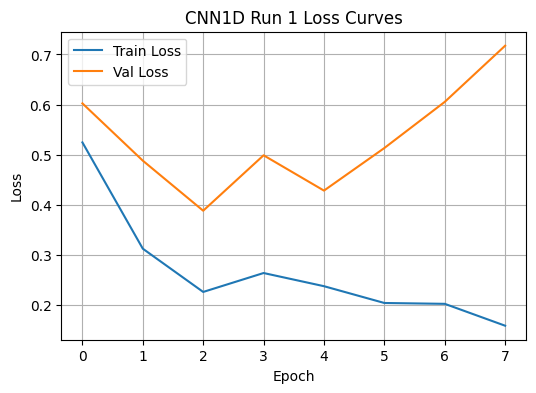


CNN1D Test Metrics:
  Accuracy:    0.8800
  Sensitivity: 0.9091
  Specificity: 0.8571
  AUC:         0.9026

Confusion Matrix:
  TN: 12, FP: 2, FN: 1, TP: 10


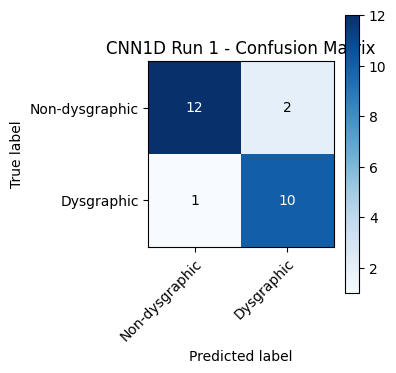


MODEL 2: TCN - Run 1

Creating TCN model with:
  in_channels: 13
  learning_rate: 0.001


Epoch 1/50 - Train Loss: 0.5154, Val Loss: 0.5087, Acc: 0.8000, Sens: 1.0000, Spec: 0.6429, AUC: 0.9610
  Best Val Loss: 0.5087 (Epoch 1), Patience: 0/5


Epoch 2/50 - Train Loss: 0.3022, Val Loss: 0.3591, Acc: 0.8800, Sens: 0.8182, Spec: 0.9286, AUC: 0.9675
  Best Val Loss: 0.3591 (Epoch 2), Patience: 0/5


Epoch 3/50 - Train Loss: 0.2240, Val Loss: 0.2894, Acc: 0.8800, Sens: 0.9091, Spec: 0.8571, AUC: 0.9545
  Best Val Loss: 0.2894 (Epoch 3), Patience: 0/5


Epoch 4/50 - Train Loss: 0.2049, Val Loss: 0.3240, Acc: 0.8000, Sens: 0.9091, Spec: 0.7143, AUC: 0.9545
  Best Val Loss: 0.2894 (Epoch 3), Patience: 1/5


...

Epoch 7/50 - Train Loss: 0.1875, Val Loss: 0.3408, Acc: 0.8000, Sens: 0.9091, Spec: 0.7143, AUC: 0.9675
  Best Val Loss: 0.2461 (Epoch 6), Patience: 1/5


Epoch 8/50 - Train Loss: 0.1334, Val Loss: 0.4557, Acc: 0.7600, Sens: 0.9091, Spec: 0.6429, AUC: 0.9545
  Best Val Loss: 0.2461 (Epoch 6), Patience: 2/5


Epoch 9/50 - Train Loss: 0.2370, Val Loss: 0.3089, Acc: 0.8800, Sens: 0.9091, Spec: 0.8571, AUC: 0.9610
  Best Val Loss: 0.2461 (Epoch 6), Patience: 3/5


Epoch 10/50 - Train Loss: 0.1380, Val Loss: 0.4209, Acc: 0.8000, Sens: 0.9091, Spec: 0.7143, AUC: 0.9481
  Best Val Loss: 0.2461 (Epoch 6), Patience: 4/5


Epoch 11/50 - Train Loss: 0.1575, Val Loss: 0.4457, Acc: 0.8000, Sens: 0.9091, Spec: 0.7143, AUC: 0.9416
  Best Val Loss: 0.2461 (Epoch 6), Patience: 5/5

Early stopping triggered at epoch 11. Best model was at epoch 6.
Restored model weights from epoch 6 (best validation loss: 0.2461)


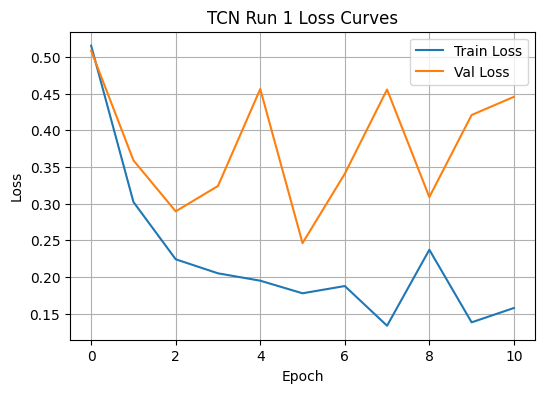


TCN Test Metrics:
  Accuracy:    0.8800
  Sensitivity: 0.9091
  Specificity: 0.8571
  AUC:         0.9675

Confusion Matrix:
  TN: 12, FP: 2, FN: 1, TP: 10


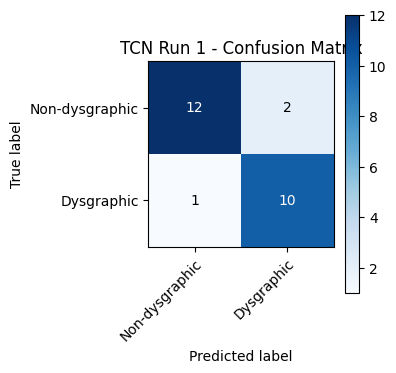


MODEL 3: CNN-LSTM - Run 1

Creating CNN-LSTM model with best hyperparameters:
  in_channels: 13
  dropout: 0.3
  learning_rate: 0.001


Epoch 1/50 - Train Loss: 0.6415, Val Loss: 0.6004, Acc: 0.9200, Sens: 1.0000, Spec: 0.8571, AUC: 0.9740
  Best Val Loss: 0.6004 (Epoch 1), Patience: 0/5


Epoch 2/50 - Train Loss: 0.4473, Val Loss: 0.4131, Acc: 0.8800, Sens: 0.9091, Spec: 0.8571, AUC: 0.9610
  Best Val Loss: 0.4131 (Epoch 2), Patience: 0/5


Epoch 3/50 - Train Loss: 0.3749, Val Loss: 0.2882, Acc: 0.8800, Sens: 0.9091, Spec: 0.8571, AUC: 0.9675
  Best Val Loss: 0.2882 (Epoch 3), Patience: 0/5


Epoch 4/50 - Train Loss: 0.2379, Val Loss: 0.2567, Acc: 0.8800, Sens: 0.8182, Spec: 0.9286, AUC: 0.9740
  Best Val Loss: 0.2567 (Epoch 4), Patience: 0/5


Epoch 5/50 - Train Loss: 0.2025, Val Loss: 0.2649, Acc: 0.9200, Sens: 0.9091, Spec: 0.9286, AUC: 0.9545
  Best Val Loss: 0.2567 (Epoch 4), Patience: 1/5


Epoch 6/50 - Train Loss: 0.1592, Val Loss: 0.3115, Acc: 0.8400, Sens: 0.9091, Spec: 0.7857, AUC: 0.9481
  Best Val Loss: 0.2567 (Epoch 4), Patience: 2/5


Epoch 7/50 - Train Loss: 0.1729, Val Loss: 0.2967, Acc: 0.8800, Sens: 0.9091, Spec: 0.8571, AUC: 0.9545
  Best Val Loss: 0.2567 (Epoch 4), Patience: 3/5


Epoch 8/50 - Train Loss: 0.1997, Val Loss: 0.2604, Acc: 0.9200, Sens: 0.9091, Spec: 0.9286, AUC: 0.9610
  Best Val Loss: 0.2567 (Epoch 4), Patience: 4/5


Epoch 9/50 - Train Loss: 0.1564, Val Loss: 0.2643, Acc: 0.9200, Sens: 0.9091, Spec: 0.9286, AUC: 0.9610
  Best Val Loss: 0.2567 (Epoch 4), Patience: 5/5

Early stopping triggered at epoch 9. Best model was at epoch 4.
Restored model weights from epoch 4 (best validation loss: 0.2567)


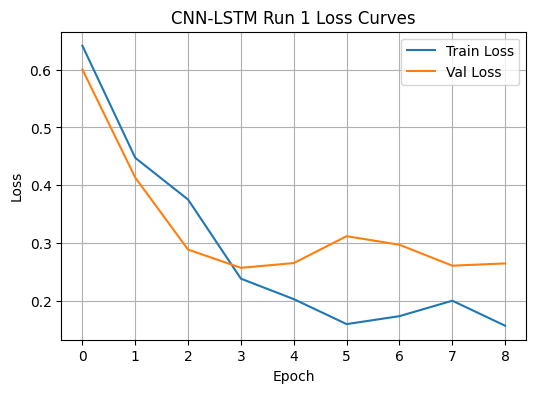


CNN-LSTM Test Metrics:
  Accuracy:    0.8800
  Sensitivity: 0.8182
  Specificity: 0.9286
  AUC:         0.9740

Confusion Matrix:
  TN: 13, FP: 1, FN: 2, TP: 9


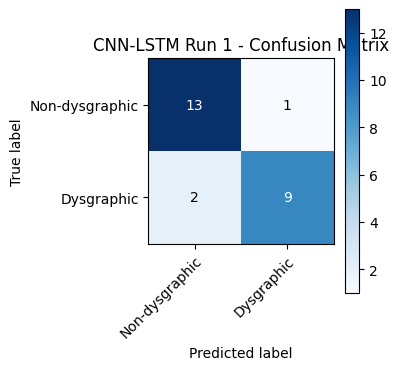


Run 1 - Summary for All Models

CNN1D:    Acc=0.8800, Sens=0.9091, Spec=0.8571, AUC=0.9026
TCN:      Acc=0.8800, Sens=0.9091, Spec=0.8571, AUC=0.9675
CNN-LSTM: Acc=0.8800, Sens=0.8182, Spec=0.9286, AUC=0.9740

Run 1 completed! All 3 models trained and evaluated.
Total runs completed: 2/1


In [ ]:
# --- 7.4 DEPRECATED: This cell is no longer needed ---
#
# NOTE: Cell 17 now automatically runs all 5 splits including model training.
# This cell is kept for reference but should not be executed.
# If you need to run individual splits, modify Cell 17 to use a loop with run_idx.

print("="*80)
print("NOTE: This cell is deprecated.")
print("Cell 17 now automatically runs all 5 splits.")
print("Please run Cell 17 instead, then proceed to Cell 19 for results.")
print("="*80)
raise SystemExit("Deprecated cell 7.4 - no training executed. Use Cell 17 instead.")

# Build full training dataset (reuse scaler from cell 17)
train_dataset = HandwritingDataset(
    train_meta, data_root=Config.DATA_ROOT, scaler=scaler,
    max_len=Config.MAX_LEN, use_derivatives=Config.USE_DERIVATIVES
)
test_dataset = HandwritingDataset(
    test_meta, data_root=Config.DATA_ROOT, scaler=scaler,
    max_len=Config.MAX_LEN, use_derivatives=Config.USE_DERIVATIVES
)

# Verify channel count consistency
sample_check = train_dataset[0]['x']
actual_channels = sample_check.shape[0]
if actual_channels != in_channels:
    print(f"WARNING: Channel mismatch detected!")
    print(f"  Expected: {in_channels}, Actual from dataset: {actual_channels}")
    print(f"  Updating in_channels to match dataset...")
    in_channels = actual_channels

print(f"Using {in_channels} input channels for all models")

train_loader = DataLoader(
    train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

# Class weights
y_train = train_meta['label'].values
classes = np.array([0, 1])
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

# Initialize storage for this run
run_models_dict = {}
run_histories_dict = {}
run_metrics_dict = {}

# ============================================================================
# MODEL 1: CNN1D
# ============================================================================
print("\n" + "="*80)
print(f"MODEL 1: CNN1D - Run {run_idx+1}")
print("="*80)

print(f"\nCreating CNN1D model with:")
print(f"  in_channels: {in_channels}")
print(f"  learning_rate: {Config.LR}")

cnn_model = CNN1DModel(in_channels=in_channels, num_classes=2)

cnn_model, cnn_history = train_one_model(
    train_loader=train_loader,
    val_loader=test_loader,
    model=cnn_model,
    num_epochs=Config.NUM_EPOCHS,
    class_weights=class_weights,
    lr=Config.LR,
    weight_decay=Config.WEIGHT_DECAY,
    device=Config.DEVICE,
    early_stopping_patience=Config.EARLY_STOPPING_PATIENCE,
    early_stopping_enabled=Config.EARLY_STOPPING_ENABLED,
)

# Plot loss curves
plot_loss_curves(cnn_history, title_prefix=f"CNN1D Run {run_idx+1}")

# Evaluate CNN
cnn_model.eval()
all_probs_cnn, all_labels_cnn = [], []
with torch.no_grad():
    for batch in test_loader:
        x = batch['x'].to(Config.DEVICE)
        y = batch['y'].to(Config.DEVICE)
        lengths = batch['length'].to(Config.DEVICE)
        logits, _ = cnn_model(x, lengths)
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_probs_cnn.append(probs.cpu().numpy())
        all_labels_cnn.append(y.cpu().numpy())

all_probs_cnn = np.concatenate(all_probs_cnn)
all_labels_cnn = np.concatenate(all_labels_cnn)
cnn_metrics = compute_metrics(all_labels_cnn, all_probs_cnn)

print(f"\nCNN1D Test Metrics:")
print(f"  Accuracy:    {cnn_metrics['accuracy']:.4f}")
print(f"  Sensitivity: {cnn_metrics['sensitivity']:.4f}")
print(f"  Specificity: {cnn_metrics['specificity']:.4f}")
print(f"  AUC:         {cnn_metrics['auc']:.4f}")

cm_cnn = cnn_metrics['confusion_matrix']
print(f"\nConfusion Matrix:")
print(f"  TN: {cm_cnn[0, 0]}, FP: {cm_cnn[0, 1]}, FN: {cm_cnn[1, 0]}, TP: {cm_cnn[1, 1]}")

plot_confusion_matrix(cnn_metrics['confusion_matrix'], title=f"CNN1D Run {run_idx+1} - Confusion Matrix")

run_models_dict['cnn'] = cnn_model
run_histories_dict['cnn'] = cnn_history
run_metrics_dict['cnn'] = cnn_metrics

# ============================================================================
# MODEL 2: TCN
# ============================================================================
print("\n" + "="*80)
print(f"MODEL 2: TCN - Run {run_idx+1}")
print("="*80)

print(f"\nCreating TCN model with:")
print(f"  in_channels: {in_channels}")
print(f"  learning_rate: {Config.LR}")

tcn_model = TCNModel(in_channels=in_channels, num_classes=2)

tcn_model, tcn_history = train_one_model(
    train_loader=train_loader,
    val_loader=test_loader,
    model=tcn_model,
    num_epochs=Config.NUM_EPOCHS,
    class_weights=class_weights,
    lr=Config.LR,
    weight_decay=Config.WEIGHT_DECAY,
    device=Config.DEVICE,
    early_stopping_patience=Config.EARLY_STOPPING_PATIENCE,
    early_stopping_enabled=Config.EARLY_STOPPING_ENABLED,
)

# Plot loss curves
plot_loss_curves(tcn_history, title_prefix=f"TCN Run {run_idx+1}")

# Evaluate TCN
tcn_model.eval()
all_probs_tcn, all_labels_tcn = [], []
with torch.no_grad():
    for batch in test_loader:
        x = batch['x'].to(Config.DEVICE)
        y = batch['y'].to(Config.DEVICE)
        lengths = batch['length'].to(Config.DEVICE)
        logits, _ = tcn_model(x, lengths)
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_probs_tcn.append(probs.cpu().numpy())
        all_labels_tcn.append(y.cpu().numpy())

all_probs_tcn = np.concatenate(all_probs_tcn)
all_labels_tcn = np.concatenate(all_labels_tcn)
tcn_metrics = compute_metrics(all_labels_tcn, all_probs_tcn)

print(f"\nTCN Test Metrics:")
print(f"  Accuracy:    {tcn_metrics['accuracy']:.4f}")
print(f"  Sensitivity: {tcn_metrics['sensitivity']:.4f}")
print(f"  Specificity: {tcn_metrics['specificity']:.4f}")
print(f"  AUC:         {tcn_metrics['auc']:.4f}")

cm_tcn = tcn_metrics['confusion_matrix']
print(f"\nConfusion Matrix:")
print(f"  TN: {cm_tcn[0, 0]}, FP: {cm_tcn[0, 1]}, FN: {cm_tcn[1, 0]}, TP: {cm_tcn[1, 1]}")

plot_confusion_matrix(tcn_metrics['confusion_matrix'], title=f"TCN Run {run_idx+1} - Confusion Matrix")

run_models_dict['tcn'] = tcn_model
run_histories_dict['tcn'] = tcn_history
run_metrics_dict['tcn'] = tcn_metrics

# ============================================================================
# MODEL 3: CNN-LSTM (with hyperparameter tuning)
# ============================================================================
print("\n" + "="*80)
print(f"MODEL 3: CNN-LSTM - Run {run_idx+1}")
print("="*80)

print(f"\nCreating CNN-LSTM model with best hyperparameters:")
print(f"  in_channels: {in_channels}")
print(f"  dropout: {best_params['dropout']}")
print(f"  learning_rate: {best_params['lr']}")

cnnlstm_model = CNNLSTMModel(
    in_channels=in_channels,
    num_classes=2,
    lstm_hidden_size=64,
    lstm_layers=2,
    dropout=best_params['dropout']
)

cnnlstm_model, cnnlstm_history = train_one_model(
    train_loader=train_loader,
    val_loader=test_loader,
    model=cnnlstm_model,
    num_epochs=Config.NUM_EPOCHS,
    class_weights=class_weights,
    lr=best_params['lr'],
    weight_decay=Config.WEIGHT_DECAY,
    device=Config.DEVICE,
    early_stopping_patience=Config.EARLY_STOPPING_PATIENCE,
    early_stopping_enabled=Config.EARLY_STOPPING_ENABLED,
)

# Plot loss curves
plot_loss_curves(cnnlstm_history, title_prefix=f"CNN-LSTM Run {run_idx+1}")

# Evaluate CNN-LSTM
cnnlstm_model.eval()
all_probs_cnnlstm, all_labels_cnnlstm = [], []
with torch.no_grad():
    for batch in test_loader:
        x = batch['x'].to(Config.DEVICE)
        y = batch['y'].to(Config.DEVICE)
        lengths = batch['length'].to(Config.DEVICE)
        logits, _ = cnnlstm_model(x, lengths)
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_probs_cnnlstm.append(probs.cpu().numpy())
        all_labels_cnnlstm.append(y.cpu().numpy())

all_probs_cnnlstm = np.concatenate(all_probs_cnnlstm)
all_labels_cnnlstm = np.concatenate(all_labels_cnnlstm)
cnnlstm_metrics = compute_metrics(all_labels_cnnlstm, all_probs_cnnlstm)

print(f"\nCNN-LSTM Test Metrics:")
print(f"  Accuracy:    {cnnlstm_metrics['accuracy']:.4f}")
print(f"  Sensitivity: {cnnlstm_metrics['sensitivity']:.4f}")
print(f"  Specificity: {cnnlstm_metrics['specificity']:.4f}")
print(f"  AUC:         {cnnlstm_metrics['auc']:.4f}")

cm_cnnlstm = cnnlstm_metrics['confusion_matrix']
print(f"\nConfusion Matrix:")
print(f"  TN: {cm_cnnlstm[0, 0]}, FP: {cm_cnnlstm[0, 1]}, FN: {cm_cnnlstm[1, 0]}, TP: {cm_cnnlstm[1, 1]}")

plot_confusion_matrix(cnnlstm_metrics['confusion_matrix'], title=f"CNN-LSTM Run {run_idx+1} - Confusion Matrix")

run_models_dict['cnnlstm'] = cnnlstm_model
run_histories_dict['cnnlstm'] = cnnlstm_history
run_metrics_dict['cnnlstm'] = cnnlstm_metrics

# ============================================================================
# Store all results
# ============================================================================
if 'all_run_metrics_cnn' not in globals():
    all_run_metrics_cnn = []
if 'all_run_metrics_tcn' not in globals():
    all_run_metrics_tcn = []
if 'all_run_metrics_cnnlstm' not in globals():
    all_run_metrics_cnnlstm = []

all_run_metrics_cnn.append(cnn_metrics)
all_run_metrics_tcn.append(tcn_metrics)
all_run_metrics_cnnlstm.append(cnnlstm_metrics)

# Store models and histories
if 'run_models' not in globals():
    run_models = {}
if 'run_histories' not in globals():
    run_histories = {}
run_models[f'run_{run_idx+1}'] = run_models_dict
run_histories[f'run_{run_idx+1}'] = run_histories_dict

# Summary for this run
print("\n" + "="*80)
print(f"Run {run_idx+1} - Summary for All Models")
print("="*80)
print(f"\nCNN1D:    Acc={cnn_metrics['accuracy']:.4f}, Sens={cnn_metrics['sensitivity']:.4f}, "
      f"Spec={cnn_metrics['specificity']:.4f}, AUC={cnn_metrics['auc']:.4f}")
print(f"TCN:      Acc={tcn_metrics['accuracy']:.4f}, Sens={tcn_metrics['sensitivity']:.4f}, "
      f"Spec={tcn_metrics['specificity']:.4f}, AUC={tcn_metrics['auc']:.4f}")
print(f"CNN-LSTM: Acc={cnnlstm_metrics['accuracy']:.4f}, Sens={cnnlstm_metrics['sensitivity']:.4f}, "
      f"Spec={cnnlstm_metrics['specificity']:.4f}, AUC={cnnlstm_metrics['auc']:.4f}")

print(f"\n{'='*80}")
print(f"Run {run_idx+1} completed! All 3 models trained and evaluated.")
print(f"Total runs completed: {len(all_run_metrics_cnn)}/{Config.NUM_REPEATED_SPLITS}")
print(f"{'='*80}")


AGGREGATED RESULTS ACROSS ALL RUNS

CNN1D - Mean ± Std across 2 runs:
  Accuracy:    0.8800 ± 0.0000
  Sensitivity: 0.9091 ± 0.0000
  Specificity: 0.8571 ± 0.0000
  AUC:         0.9058 ± 0.0032

Individual Run Results:
  Run 1: Acc=0.8800, Sens=0.9091, Spec=0.8571, AUC=0.9091
  Run 2: Acc=0.8800, Sens=0.9091, Spec=0.8571, AUC=0.9026

TCN - Mean ± Std across 2 runs:
  Accuracy:    0.8600 ± 0.0200
  Sensitivity: 0.9091 ± 0.0000
  Specificity: 0.8214 ± 0.0357
  AUC:         0.9513 ± 0.0162

Individual Run Results:
  Run 1: Acc=0.8400, Sens=0.9091, Spec=0.7857, AUC=0.9351
  Run 2: Acc=0.8800, Sens=0.9091, Spec=0.8571, AUC=0.9675

CNN-LSTM - Mean ± Std across 2 runs:
  Accuracy:    0.9000 ± 0.0200
  Sensitivity: 0.8636 ± 0.0455
  Specificity: 0.9286 ± 0.0000
  AUC:         0.9740 ± 0.0000

Individual Run Results:
  Run 1: Acc=0.9200, Sens=0.9091, Spec=0.9286, AUC=0.9740
  Run 2: Acc=0.8800, Sens=0.8182, Spec=0.9286, AUC=0.9740

--------------------------------------------------------------

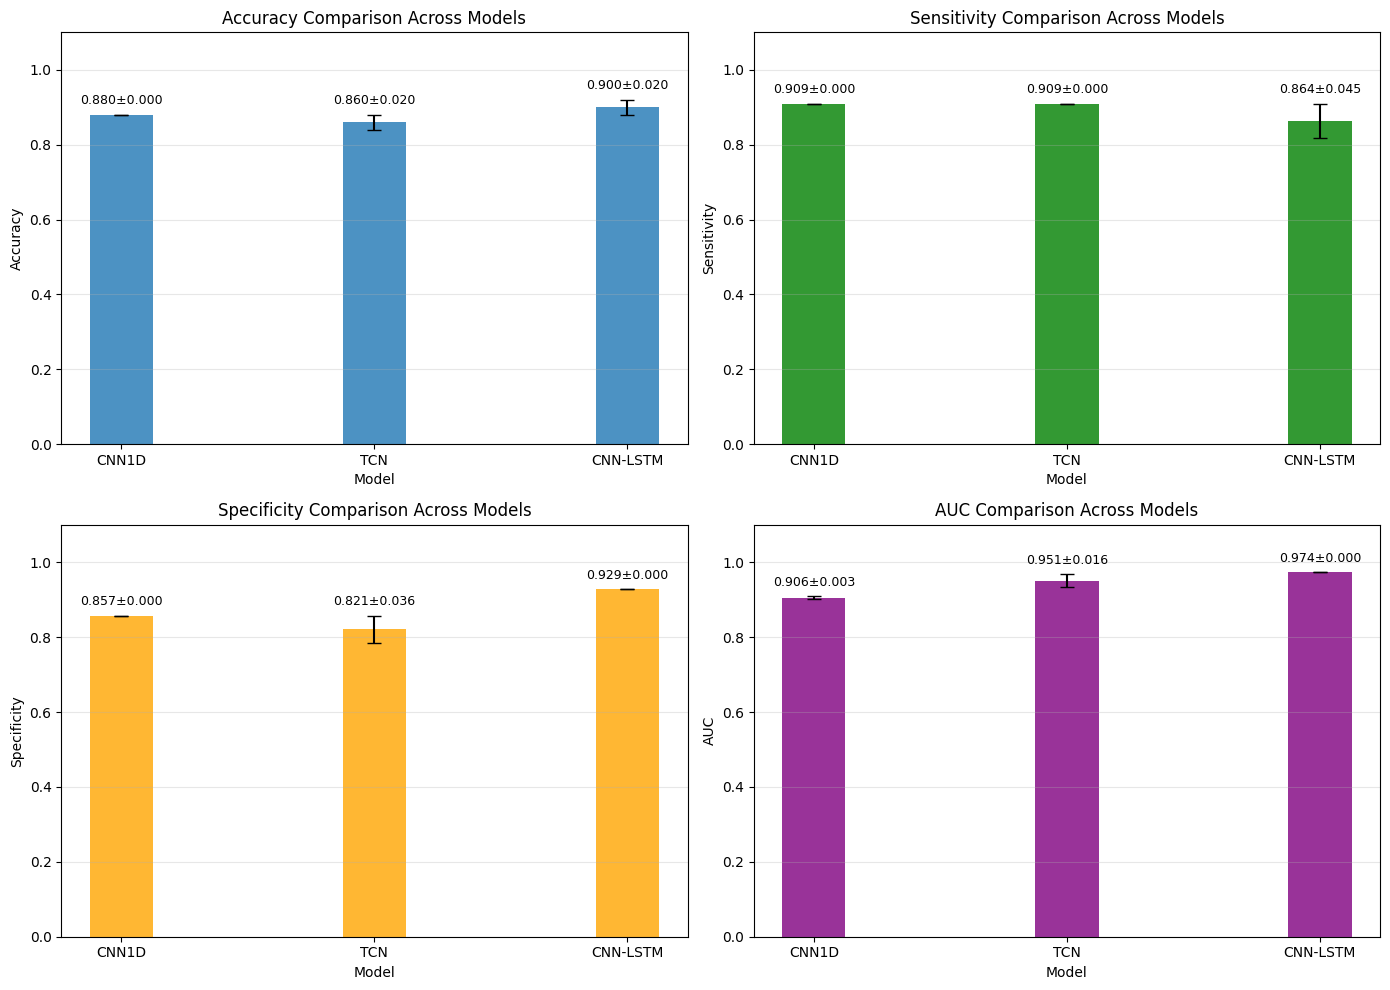

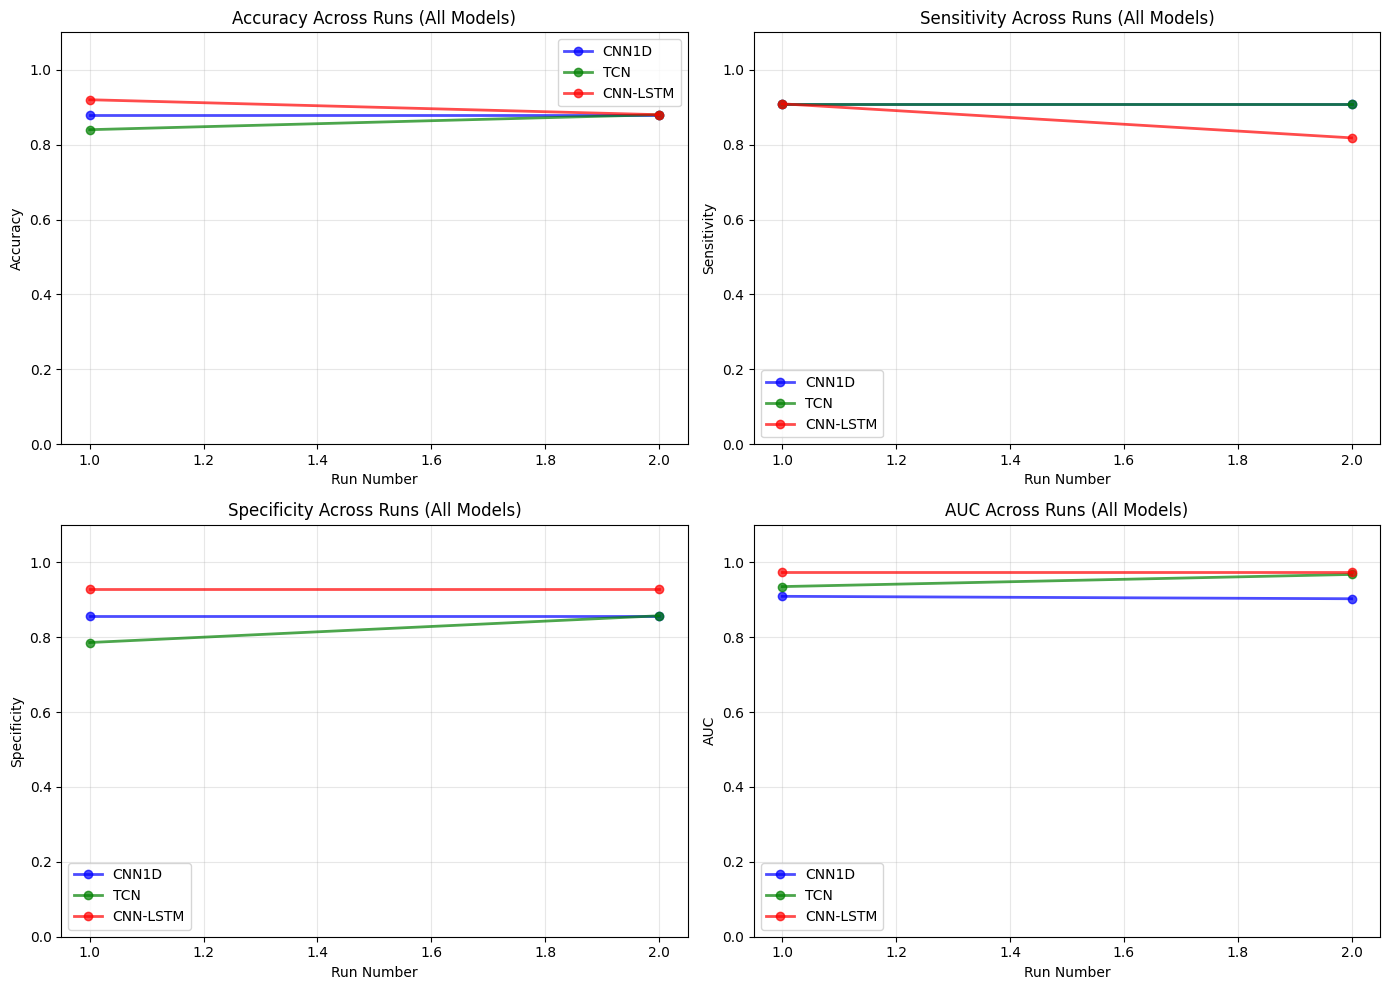

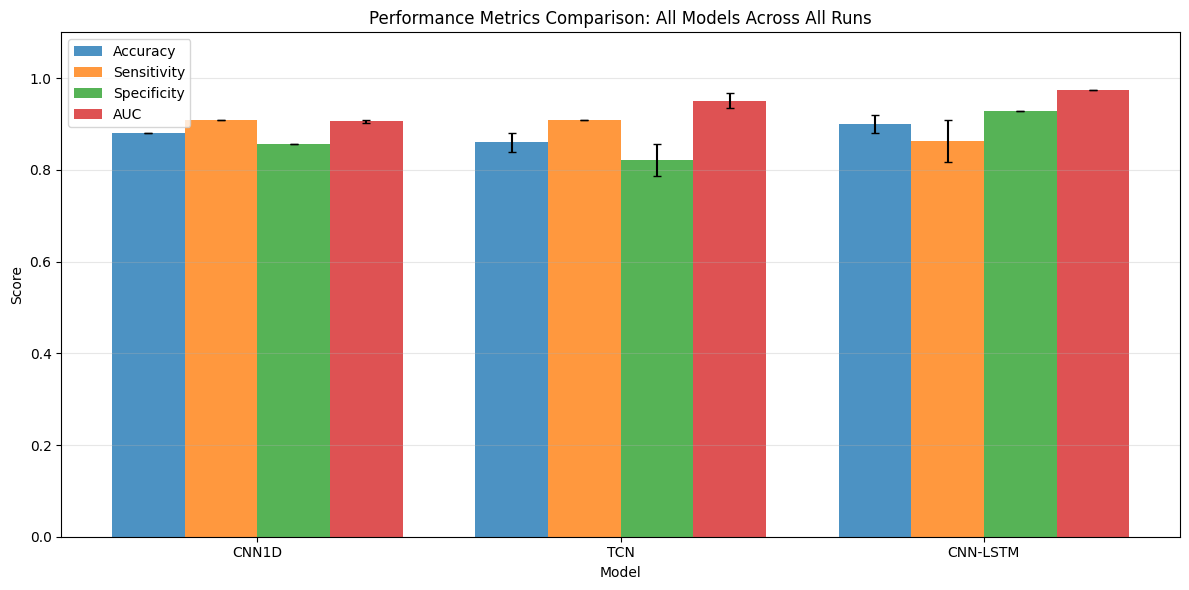

In [ ]:
# --- 7.5 Aggregate Results Across All Runs ---
#
# Run this cell after completing all runs to see aggregated results.

print("\n" + "="*80)
print("AGGREGATED RESULTS ACROSS ALL RUNS")
print("="*80)

def aggregate_metrics(metrics_list, model_name):
    """Aggregate and print metrics across multiple runs."""
    if not metrics_list:
        print(f"No metrics for {model_name}")
        return

    # Safely extract metrics with error handling
    try:
        accs = np.array([m.get('accuracy', 0.0) for m in metrics_list])
        sens = np.array([m.get('sensitivity', 0.0) for m in metrics_list])
        spec = np.array([m.get('specificity', 0.0) for m in metrics_list])
        # Extract AUC values, handling NaN and missing keys
        aucs = np.array([m.get('auc', np.nan) for m in metrics_list])
        aucs = aucs[~np.isnan(aucs)]  # Filter out NaN values
    except (KeyError, TypeError, ValueError) as e:
        print(f"Error extracting metrics for {model_name}: {e}")
        return

    if len(metrics_list) == 1:
        # Single run - no standard deviation
        print(f"\n{model_name} - Results (Single Run):")
        print(f"  Accuracy:    {accs[0]:.4f}")
        print(f"  Sensitivity: {sens[0]:.4f}")
        print(f"  Specificity: {spec[0]:.4f}")
    else:
        # Multiple runs - show mean and std
        print(f"\n{model_name} - Mean ± Std across {len(metrics_list)} runs:")
        print(f"  Accuracy:    {accs.mean():.4f} ± {accs.std():.4f}")
        print(f"  Sensitivity: {sens.mean():.4f} ± {sens.std():.4f}")
        print(f"  Specificity: {spec.mean():.4f} ± {spec.std():.4f}")
    if len(aucs) > 0:
        if len(metrics_list) == 1:
            print(f"  AUC:         {aucs[0]:.4f}")
        else:
            print(f"  AUC:         {aucs.mean():.4f} ± {aucs.std():.4f}")
    else:
        print(f"  AUC:         N/A (all NaN)")

    # Print individual run results
    print(f"\nIndividual Run Results:")
    for i, m in enumerate(metrics_list, 1):
        # Format AUC separately to handle NaN values
        auc_str = f"{m['auc']:.4f}" if not np.isnan(m['auc']) else "N/A"
        print(f"  Run {i}: Acc={m['accuracy']:.4f}, Sens={m['sensitivity']:.4f}, "
              f"Spec={m['specificity']:.4f}, AUC={auc_str}")

# Check which models have results
models_to_aggregate = []
if 'all_run_metrics_cnn' in globals() and len(all_run_metrics_cnn) > 0:
    models_to_aggregate.append(('CNN1D', all_run_metrics_cnn))
if 'all_run_metrics_tcn' in globals() and len(all_run_metrics_tcn) > 0:
    models_to_aggregate.append(('TCN', all_run_metrics_tcn))
if 'all_run_metrics_cnnlstm' in globals() and len(all_run_metrics_cnnlstm) > 0:
    models_to_aggregate.append(('CNN-LSTM', all_run_metrics_cnnlstm))

if len(models_to_aggregate) > 0:
    # Aggregate metrics for each model
    for model_name, metrics_list in models_to_aggregate:
        aggregate_metrics(metrics_list, model_name)

    # Check if we have multiple runs for meaningful visualizations
    num_runs = max(len(m) for _, m in models_to_aggregate) if models_to_aggregate else 0

    if num_runs < 2:
        print("\n" + "="*80)
        print("VISUALIZATION NOTE")
        print("="*80)
        print(f"Only {num_runs} run(s) completed. Visualizations require at least 2 runs.")
        print("Please run Cell 17 to complete all 5 splits for meaningful visualizations.")
        print("="*80)
    else:
        # Create summary visualization comparing all 3 models
        print("\n" + "-"*80)
        print("Summary Visualization: Comparing All 3 Models")
        print(f"(Based on {num_runs} runs)")
        print("-"*80)

        # Prepare data for comparison
        model_names = []
        all_accs = []
        all_sens = []
        all_spec = []
        all_aucs = []

        for model_name, metrics_list in models_to_aggregate:
            model_names.append(model_name)
            all_accs.append(np.array([m['accuracy'] for m in metrics_list]))
            all_sens.append(np.array([m['sensitivity'] for m in metrics_list]))
            all_spec.append(np.array([m['specificity'] for m in metrics_list]))
            aucs = np.array([m['auc'] for m in metrics_list if not np.isnan(m['auc'])])
            all_aucs.append(aucs if len(aucs) > 0 else np.array([]))

        # Plot 1: Metrics comparison across models (bar chart)
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        x = np.arange(len(model_names))
        width = 0.25

        # Calculate means
        acc_means = [acc.mean() for acc in all_accs]
        sens_means = [sens.mean() for sens in all_sens]
        spec_means = [spec.mean() for spec in all_spec]
        auc_means = [auc.mean() if len(auc) > 0 else np.nan for auc in all_aucs]

        # Calculate stds
        acc_stds = [acc.std() for acc in all_accs]
        sens_stds = [sens.std() for sens in all_sens]
        spec_stds = [spec.std() for spec in all_spec]
        auc_stds = [auc.std() if len(auc) > 0 else np.nan for auc in all_aucs]

        # Accuracy comparison
        axes[0, 0].bar(x, acc_means, width, yerr=acc_stds, label='Accuracy', alpha=0.8, capsize=5)
        axes[0, 0].set_xlabel('Model')
        axes[0, 0].set_ylabel('Accuracy')
        axes[0, 0].set_title('Accuracy Comparison Across Models')
        axes[0, 0].set_xticks(x)
        axes[0, 0].set_xticklabels(model_names)
        axes[0, 0].set_ylim([0, 1.1])
        axes[0, 0].grid(True, alpha=0.3, axis='y')
        for i, (mean, std) in enumerate(zip(acc_means, acc_stds)):
            axes[0, 0].text(i, mean + std + 0.02, f'{mean:.3f}±{std:.3f}',
                            ha='center', va='bottom', fontsize=9)

        # Sensitivity comparison
        axes[0, 1].bar(x, sens_means, width, yerr=sens_stds, label='Sensitivity',
                       alpha=0.8, capsize=5, color='green')
        axes[0, 1].set_xlabel('Model')
        axes[0, 1].set_ylabel('Sensitivity')
        axes[0, 1].set_title('Sensitivity Comparison Across Models')
        axes[0, 1].set_xticks(x)
        axes[0, 1].set_xticklabels(model_names)
        axes[0, 1].set_ylim([0, 1.1])
        axes[0, 1].grid(True, alpha=0.3, axis='y')
        for i, (mean, std) in enumerate(zip(sens_means, sens_stds)):
            axes[0, 1].text(i, mean + std + 0.02, f'{mean:.3f}±{std:.3f}',
                            ha='center', va='bottom', fontsize=9)

        # Specificity comparison
        axes[1, 0].bar(x, spec_means, width, yerr=spec_stds, label='Specificity',
                      alpha=0.8, capsize=5, color='orange')
        axes[1, 0].set_xlabel('Model')
        axes[1, 0].set_ylabel('Specificity')
        axes[1, 0].set_title('Specificity Comparison Across Models')
        axes[1, 0].set_xticks(x)
        axes[1, 0].set_xticklabels(model_names)
        axes[1, 0].set_ylim([0, 1.1])
        axes[1, 0].grid(True, alpha=0.3, axis='y')
        for i, (mean, std) in enumerate(zip(spec_means, spec_stds)):
            axes[1, 0].text(i, mean + std + 0.02, f'{mean:.3f}±{std:.3f}',
                            ha='center', va='bottom', fontsize=9)

        # AUC comparison
        valid_auc_means = [m for m in auc_means if not np.isnan(m)]
        valid_auc_stds = [s for s, m in zip(auc_stds, auc_means) if not np.isnan(m)]
        valid_model_names = [n for n, m in zip(model_names, auc_means) if not np.isnan(m)]
        if len(valid_auc_means) > 0:
            x_auc = np.arange(len(valid_model_names))
            axes[1, 1].bar(x_auc, valid_auc_means, width, yerr=valid_auc_stds,
                          label='AUC', alpha=0.8, capsize=5, color='purple')
            axes[1, 1].set_xlabel('Model')
            axes[1, 1].set_ylabel('AUC')
            axes[1, 1].set_title('AUC Comparison Across Models')
            axes[1, 1].set_xticks(x_auc)
            axes[1, 1].set_xticklabels(valid_model_names)
            axes[1, 1].set_ylim([0, 1.1])
            axes[1, 1].grid(True, alpha=0.3, axis='y')
            for i, (mean, std) in enumerate(zip(valid_auc_means, valid_auc_stds)):
                axes[1, 1].text(i, mean + std + 0.02, f'{mean:.3f}±{std:.3f}',
                                ha='center', va='bottom', fontsize=9)
        else:
            axes[1, 1].text(0.5, 0.5, 'AUC not available', ha='center', va='center',
                            transform=axes[1, 1].transAxes)
            axes[1, 1].set_title('AUC Comparison Across Models')

        plt.tight_layout()
        plt.show()

        # Plot 2: Line plots showing metrics across runs for each model
        num_runs_plot = max(len(m) for _, m in models_to_aggregate)
        runs = np.arange(1, num_runs_plot + 1)

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        colors = ['blue', 'green', 'red', 'purple', 'orange']

        for idx, (model_name, metrics_list) in enumerate(models_to_aggregate):
            accs = np.array([m['accuracy'] for m in metrics_list])
            sens = np.array([m['sensitivity'] for m in metrics_list])
            spec = np.array([m['specificity'] for m in metrics_list])
            aucs = np.array([m['auc'] for m in metrics_list if not np.isnan(m['auc'])])

            model_runs = np.arange(1, len(metrics_list) + 1)
            color = colors[idx % len(colors)]

            # Accuracy
            axes[0, 0].plot(model_runs, accs, 'o-', linewidth=2, markersize=6,
                           label=model_name, color=color, alpha=0.7)

            # Sensitivity
            axes[0, 1].plot(model_runs, sens, 'o-', linewidth=2, markersize=6,
                           label=model_name, color=color, alpha=0.7)

            # Specificity
            axes[1, 0].plot(model_runs, spec, 'o-', linewidth=2, markersize=6,
                           label=model_name, color=color, alpha=0.7)

            # AUC
            if len(aucs) > 0:
                axes[1, 1].plot(model_runs[:len(aucs)], aucs, 'o-', linewidth=2, markersize=6,
                               label=model_name, color=color, alpha=0.7)

        axes[0, 0].set_xlabel('Run Number')
        axes[0, 0].set_ylabel('Accuracy')
        axes[0, 0].set_title('Accuracy Across Runs (All Models)')
        axes[0, 0].set_ylim([0, 1.1])
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].legend()

        axes[0, 1].set_xlabel('Run Number')
        axes[0, 1].set_ylabel('Sensitivity')
        axes[0, 1].set_title('Sensitivity Across Runs (All Models)')
        axes[0, 1].set_ylim([0, 1.1])
        axes[0, 1].grid(True, alpha=0.3)
        axes[0, 1].legend()

        axes[1, 0].set_xlabel('Run Number')
        axes[1, 0].set_ylabel('Specificity')
        axes[1, 0].set_title('Specificity Across Runs (All Models)')
        axes[1, 0].set_ylim([0, 1.1])
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].legend()

        axes[1, 1].set_xlabel('Run Number')
        axes[1, 1].set_ylabel('AUC')
        axes[1, 1].set_title('AUC Across Runs (All Models)')
        axes[1, 1].set_ylim([0, 1.1])
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].legend()

        plt.tight_layout()
        plt.show()

        # Plot 3: Side-by-side bar chart for all metrics across all models
        fig, ax = plt.subplots(figsize=(12, 6))
        x = np.arange(len(model_names))
        width = 0.2

        ax.bar(x - 1.5*width, acc_means, width, yerr=acc_stds, label='Accuracy', alpha=0.8, capsize=3)
        ax.bar(x - 0.5*width, sens_means, width, yerr=sens_stds, label='Sensitivity', alpha=0.8, capsize=3)
        ax.bar(x + 0.5*width, spec_means, width, yerr=spec_stds, label='Specificity', alpha=0.8, capsize=3)
        if not all(np.isnan(auc_means)):
            valid_auc = [m if not np.isnan(m) else 0 for m in auc_means]
            valid_auc_err = [s if not np.isnan(s) else 0 for s in auc_stds]
            ax.bar(x + 1.5*width, valid_auc, width, yerr=valid_auc_err, label='AUC', alpha=0.8, capsize=3)

        ax.set_xlabel('Model')
        ax.set_ylabel('Score')
        ax.set_title('Performance Metrics Comparison: All Models Across All Runs')
        ax.set_xticks(x)
        ax.set_xticklabels(model_names)
        ax.set_ylim([0, 1.1])
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()

else:
    print("\nNo results found. Please run cells 17 and 18 for each split first.")

## 8. Feature Ablation Study

This section performs an ablation study to understand the importance of each feature channel.
We systematically remove (zero out) each feature channel and measure the performance degradation.

FEATURE ABLATION STUDY

Training model for ablation study...


Epoch 1/30 - Train Loss: 0.6369, Val Loss: 0.5811, Acc: 0.8400, Sens: 0.8182, Spec: 0.8571, AUC: 0.9545
  Best Val Loss: 0.5811 (Epoch 1), Patience: 0/5


Epoch 2/30 - Train Loss: 0.4124, Val Loss: 0.3819, Acc: 0.8400, Sens: 0.8182, Spec: 0.8571, AUC: 0.9610
  Best Val Loss: 0.3819 (Epoch 2), Patience: 0/5


Epoch 3/30 - Train Loss: 0.2957, Val Loss: 0.2969, Acc: 0.8800, Sens: 0.8182, Spec: 0.9286, AUC: 0.9545
  Best Val Loss: 0.2969 (Epoch 3), Patience: 0/5


Epoch 4/30 - Train Loss: 0.3116, Val Loss: 0.3006, Acc: 0.8400, Sens: 0.9091, Spec: 0.7857, AUC: 0.9481
  Best Val Loss: 0.2969 (Epoch 3), Patience: 1/5


Epoch 5/30 - Train Loss: 0.2932, Val Loss: 0.4303, Acc: 0.8800, Sens: 0.8182, Spec: 0.9286, AUC: 0.9091
  Best Val Loss: 0.2969 (Epoch 3), Patience: 2/5


Epoch 6/30 - Train Loss: 0.1942, Val Loss: 0.4762, Acc: 0.8400, Sens: 0.8182, Spec: 0.8571, AUC: 0.9221
  Best Val Loss: 0.2969 (Epoch 3), Patience: 3/5


Epoch 7/30 - Train Loss: 0.1574, Val Loss: 0.4747, Acc: 0.8800, Sens: 0.8182, Spec: 0.9286, AUC: 0.9156
  Best Val Loss: 0.2969 (Epoch 3), Patience: 4/5


Epoch 8/30 - Train Loss: 0.2089, Val Loss: 0.5018, Acc: 0.8400, Sens: 0.7273, Spec: 0.9286, AUC: 0.8961
  Best Val Loss: 0.2969 (Epoch 3), Patience: 5/5

Early stopping triggered at epoch 8. Best model was at epoch 3.
Restored model weights from epoch 3 (best validation loss: 0.2969)

Baseline Performance (All Features):
  Accuracy: 0.8800, AUC: 0.9545

Ablating channel 0 (X)...
  AUC: 0.9545 (drop: 0.0000), Acc: 0.8800 (drop: 0.0000)

Ablating channel 1 (Y)...
  AUC: 0.9740 (drop: -0.0195), Acc: 0.8400 (drop: 0.0400)

Ablating channel 2 (Time)...
  AUC: 0.6623 (drop: 0.2922), Acc: 0.4400 (drop: 0.4400)

Ablating channel 3 (Pressure)...
  AUC: 0.9740 (drop: -0.0195), Acc: 0.9200 (drop: -0.0400)

Ablating channel 4 (Azimuth)...
  AUC: 0.9740 (drop: -0.0195), Acc: 0.9200 (drop: -0.0400)

Ablating channel 5 (Altitude)...
  AUC: 0.9675 (drop: -0.0130), Acc: 0.9200 (drop: -0.0400)

Ablating channel 6 (Pen_Status)...
  AUC: 0.9545 (drop: 0.0000), Acc: 0.8400 (drop: 0.0400)

Ablating channel 

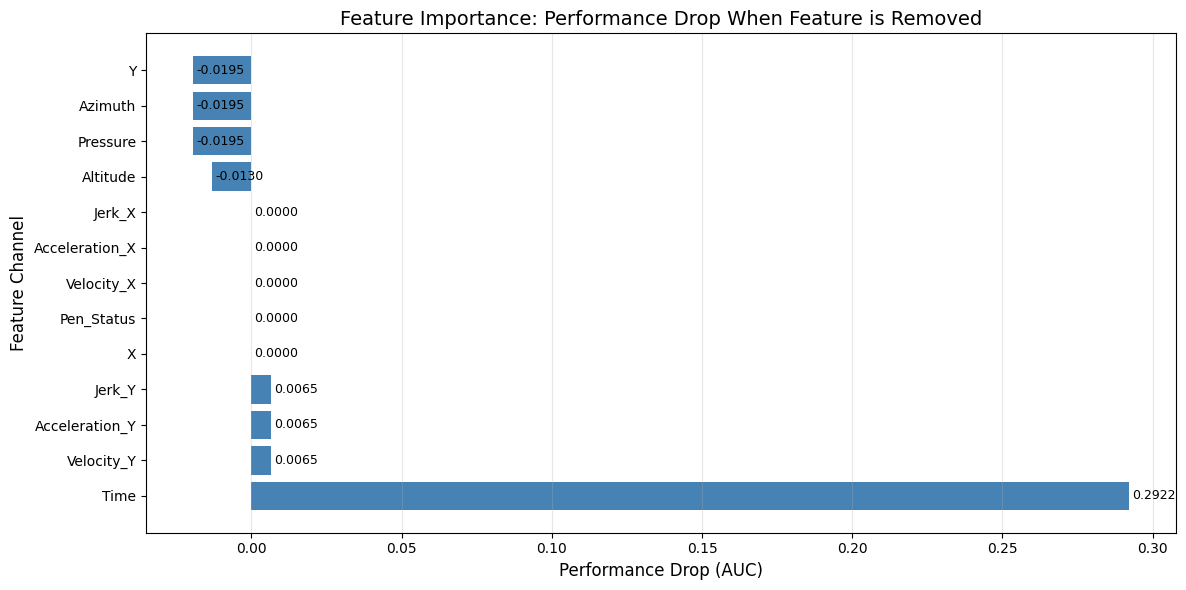


Feature Importance Ranking (Most Important First):
 1. Time                 - AUC Drop: 0.2922, Acc Drop: 0.4400
 2. Velocity_Y           - AUC Drop: 0.0065, Acc Drop: 0.0000
 3. Acceleration_Y       - AUC Drop: 0.0065, Acc Drop: 0.0800
 4. Jerk_Y               - AUC Drop: 0.0065, Acc Drop: 0.0000
 5. X                    - AUC Drop: 0.0000, Acc Drop: 0.0000
 6. Pen_Status           - AUC Drop: 0.0000, Acc Drop: 0.0400
 7. Velocity_X           - AUC Drop: 0.0000, Acc Drop: 0.0000
 8. Acceleration_X       - AUC Drop: 0.0000, Acc Drop: 0.0000
 9. Jerk_X               - AUC Drop: 0.0000, Acc Drop: 0.0000
10. Altitude             - AUC Drop: -0.0130, Acc Drop: -0.0400


In [ ]:
import re
# --- 8.1 Feature Ablation Study ---

"""
Feature Ablation Study:
For each feature channel, we zero it out in the test set and measure performance degradation.
The importance of a feature is inversely proportional to the performance drop when it's removed.
"""

# Note: This requires a trained model from Section 7
# We'll use the last trained model from the repeated splits

print("=" * 80)
print("FEATURE ABLATION STUDY")
print("=" * 80)

# Use the last split's train/test data and model
# For this example, we'll create a simple train/test split
train_meta_abl, test_meta_abl = subject_independent_split(
    meta_df, train_ratio=Config.TRAIN_SUBJECT_RATIO, random_state=42
)

# Fit scaler
train_raw_abl = []
for _, row in train_meta_abl.iterrows():
    filepath = os.path.join(Config.DATA_ROOT, row['file_name'])
    if not os.path.exists(filepath):
        continue
    ts = load_raw_timeseries(filepath)
    if Config.USE_DERIVATIVES:
        ts = compute_derivatives(ts)
    train_raw_abl.append(ts)

scaler_abl = fit_scaler_on_train(train_raw_abl)

# Correctly determine in_channels_abl: The train_raw_abl already contains samples with derivatives.
# So, we can directly get the channel count from the first sample in train_raw_abl.
# The previous code was applying compute_derivatives a second time here.
if train_raw_abl:
    in_channels_abl = train_raw_abl[0].shape[1]
else:
    raise ValueError("train_raw_abl is empty, cannot determine input channels.")

# Train a model for ablation (using default hyperparameters for speed)
print("\nTraining model for ablation study...")
train_dataset_abl = HandwritingDataset(
    train_meta_abl, data_root=Config.DATA_ROOT, scaler=scaler_abl,
    max_len=Config.MAX_LEN, use_derivatives=Config.USE_DERIVATIVES
)
test_dataset_abl = HandwritingDataset(
    test_meta_abl, data_root=Config.DATA_ROOT, scaler=scaler_abl,
    max_len=Config.MAX_LEN, use_derivatives=Config.USE_DERIVATIVES
)

train_loader_abl = DataLoader(train_dataset_abl, batch_size=Config.BATCH_SIZE, shuffle=True)
test_loader_abl = DataLoader(test_dataset_abl, batch_size=Config.BATCH_SIZE, shuffle=False)

y_train_abl = train_meta_abl['label'].values
classes = np.array([0, 1])
class_weights_abl = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_abl)

ablation_model = CNNLSTMModel(in_channels=in_channels_abl, num_classes=2, dropout=0.3)
ablation_model, _ = train_one_model(
    train_loader=train_loader_abl,
    val_loader=test_loader_abl,
    model=ablation_model,
    num_epochs=30,  # Fewer epochs for ablation study
    class_weights=class_weights_abl,
    lr=1e-3,
    weight_decay=Config.WEIGHT_DECAY,
    device=Config.DEVICE,
    early_stopping_patience=5,
    early_stopping_enabled=True,
)

# Baseline performance (all features)
ablation_model.eval()
all_probs_baseline, all_labels_baseline = [], []
with torch.no_grad():
    for batch in test_loader_abl:
        x = batch['x'].to(Config.DEVICE)
        y = batch['y'].to(Config.DEVICE)
        lengths = batch['length'].to(Config.DEVICE)
        logits, _ = ablation_model(x, lengths)
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_probs_baseline.append(probs.cpu().numpy())
        all_labels_baseline.append(y.cpu().numpy())

all_probs_baseline = np.concatenate(all_probs_baseline)
all_labels_baseline = np.concatenate(all_labels_baseline)
baseline_metrics = compute_metrics(all_labels_baseline, all_probs_baseline)
baseline_auc = baseline_metrics['auc'] if not np.isnan(baseline_metrics['auc']) else baseline_metrics['accuracy']
baseline_acc = baseline_metrics['accuracy']

print(f"\nBaseline Performance (All Features):")
print(f"  Accuracy: {baseline_acc:.4f}, AUC: {baseline_auc:.4f}")

# Feature names (approximate - adjust based on your actual feature order)
# Assuming: x, y, t, pressure, azimuth, altitude, pen_status, vx, vy, ax, ay, jx, jy
feature_names = ['X', 'Y', 'Time', 'Pressure', 'Azimuth', 'Altitude', 'Pen_Status',
                 'Velocity_X', 'Velocity_Y', 'Acceleration_X', 'Acceleration_Y',
                 'Jerk_X', 'Jerk_Y'][:in_channels_abl]

# Ablation: Remove each feature channel
ablation_results = []

for channel_idx in range(in_channels_abl):
    print(f"\nAblating channel {channel_idx} ({feature_names[channel_idx] if channel_idx < len(feature_names) else f'Channel_{channel_idx}'})...")

    # Create modified test dataset with this channel zeroed out
    all_probs_abl, all_labels_abl = [], []

    with torch.no_grad():
        for batch in test_loader_abl:
            x = batch['x'].to(Config.DEVICE).clone()
            y = batch['y'].to(Config.DEVICE)
            lengths = batch['length'].to(Config.DEVICE)

            # Zero out the specific channel
            x[:, channel_idx, :] = 0.0

            logits, _ = ablation_model(x, lengths)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs_abl.append(probs.cpu().numpy())
            all_labels_abl.append(y.cpu().numpy())

    all_probs_abl = np.concatenate(all_probs_abl)
    all_labels_abl = np.concatenate(all_labels_abl)
    metrics_abl = compute_metrics(all_labels_abl, all_probs_abl)

    auc_abl = metrics_abl['auc'] if not np.isnan(metrics_abl['auc']) else metrics_abl['accuracy']
    acc_abl = metrics_abl['accuracy']

    # Calculate performance drop
    auc_drop = baseline_auc - auc_abl
    acc_drop = baseline_acc - acc_abl

    feature_name = feature_names[channel_idx] if channel_idx < len(feature_names) else f'Channel_{channel_idx}'
    ablation_results.append({
        'channel': channel_idx,
        'feature_name': feature_name,
        'baseline_auc': baseline_auc,
        'ablated_auc': auc_abl,
        'auc_drop': auc_drop,
        'baseline_acc': baseline_acc,
        'ablated_acc': acc_abl,
        'acc_drop': acc_drop,
    })

    print(f"  AUC: {auc_abl:.4f} (drop: {auc_drop:.4f}), Acc: {acc_abl:.4f} (drop: {acc_drop:.4f})")

# Sort by importance (largest drop = most important)
ablation_results.sort(key=lambda x: x['auc_drop'], reverse=True)

# Plot feature importance
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE (based on AUC drop)")
print("=" * 80)

fig, ax = plt.subplots(figsize=(12, 6))
features = [r['feature_name'] for r in ablation_results]
auc_drops = [r['auc_drop'] for r in ablation_results]

bars = ax.barh(features, auc_drops, color='steelblue')
ax.set_xlabel('Performance Drop (AUC)', fontsize=12)
ax.set_ylabel('Feature Channel', fontsize=12)
ax.set_title('Feature Importance: Performance Drop When Feature is Removed', fontsize=14)
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (bar, drop) in enumerate(zip(bars, auc_drops)):
    ax.text(drop + 0.001, i, f'{drop:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary
print("\nFeature Importance Ranking (Most Important First):")
for i, result in enumerate(ablation_results[:10], 1):  # Top 10
    print(f"{i:2d}. {result['feature_name']:20s} - AUC Drop: {result['auc_drop']:.4f}, Acc Drop: {result['acc_drop']:.4f}")


## 9. TSInterpret Integration (Explainable AI)

This section integrates the TSInterpret library for time-series interpretability.

**TSInterpret** provides various interpretability methods for time-series classifiers, including:
- Feature attribution methods (e.g., Integrated Gradients, SHAP)
- Counterfactual explanations (if available)
- Saliency maps

We will demonstrate how to use TSInterpret to understand model predictions for dysgraphia detection.

In [ ]:
# --- 9.0 Install TSInterpret (Fresh Installation) ---

"""
Install TSInterpret library from scratch.

This cell will try multiple installation methods:
1. pip install TSInterpret (from PyPI)
2. pip install from GitHub (if PyPI fails)

GitHub: https://github.com/fzi-forschungszentrum-informatik/TSInterpret

IMPORTANT: After installation, RESTART THE KERNEL before proceeding to Section 9.1
"""
!pip install TSInterpret
print("="*80)
print("INSTALLING TSINTERPRET FROM SCRATCH")
print("="*80)
print("\nMethod 1: Installing from PyPI...")
print("-"*80)

import sys
import subprocess

# Method 1: Try PyPI installation
try:
    from IPython import get_ipython
    ipython = get_ipython()
    if ipython is not None:
        # Use magic command
        print("Using Jupyter magic command...")
        ipython.run_line_magic('pip', 'install --upgrade TSInterpret')
        print("\n✓ PyPI installation completed!")
    else:
        raise AttributeError("Not in Jupyter")
except (ImportError, AttributeError):
    # Fallback to subprocess
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", "--upgrade", "TSInterpret"],
        capture_output=False,
        text=True
    )
    if result.returncode == 0:
        print("\n✓ PyPI installation completed!")
    else:
        print("\n⚠ PyPI installation may have failed. Trying GitHub...")
        print("\n" + "-"*80)
        print("Method 2: Installing from GitHub...")
        print("-"*80)

        # Method 2: Install from GitHub
        github_url = "https://github.com/fzi-forschungszentrum-informatik/TSInterpret/archive/refs/heads/main.zip"
        try:
            if ipython is not None:
                ipython.run_line_magic('pip', f'install --upgrade {github_url}')
            else:
                subprocess.run(
                    [sys.executable, "-m", "pip", "install", "--upgrade", github_url],
                    capture_output=False,
                    text=True
                )
            print("\n✓ GitHub installation completed!")
        except Exception as e:
            print(f"\n✗ GitHub installation failed: {e}")
            print("\nPlease try manually:")
            print("  !pip install TSInterpret")
            print("  OR")
            print(f"  !pip install {github_url}")

print("\n" + "="*80)
print("INSTALLATION COMPLETE")
print("="*80)
print("\n⚠ CRITICAL: RESTART THE KERNEL NOW!")
print("  1. Go to: Kernel -> Restart Kernel")
print("  2. Re-run this cell to verify installation")
print("  3. Then proceed to Section 9.1")
print("="*80)

INSTALLING TSINTERPRET FROM SCRATCH

Method 1: Installing from PyPI...
--------------------------------------------------------------------------------
Using Jupyter magic command...

✓ PyPI installation completed!

INSTALLATION COMPLETE

⚠ CRITICAL: RESTART THE KERNEL NOW!
  1. Go to: Kernel -> Restart Kernel
  2. Re-run this cell to verify installation
  3. Then proceed to Section 9.1


In [ ]:
# --- 9.1 TSInterpret Integration & Verification ---

"""
Verify TSInterpret installation and explore available methods.

This cell will:
1. Verify TSInterpret is installed correctly
2. Show available interpretability methods
3. Demonstrate basic usage with our trained model
"""

print("="*80)
print("TSINTERPRET VERIFICATION & INTEGRATION")
print("="*80)

# Step 1: Verify installation
try:
    import TSInterpret
    print("\n✓ TSInterpret package imported successfully!")

    # Show package info
    import os
    ts_path = os.path.dirname(TSInterpret.__file__)
    print(f"  Installation path: {ts_path}")

    # Step 2: Explore available methods
    print("\n" + "-"*80)
    print("EXPLORING AVAILABLE METHODS")
    print("-"*80)

    # Check what's available
    import inspect
    import pkgutil

    available_methods = []

    # Try to find InterpretabilityModels
    try:
        from TSInterpret import InterpretabilityModels
        print("✓ Found InterpretabilityModels module")

        # List submodules
        for importer, modname, ispkg in pkgutil.iter_modules(InterpretabilityModels.__path__, InterpretabilityModels.__name__ + "."):
            if ispkg:
                print(f"  - {modname}")
                available_methods.append(modname)

                # Try to list classes in each submodule
                try:
                    module = __import__(modname, fromlist=[''])
                    classes = [name for name, obj in inspect.getmembers(module, inspect.isclass)
                              if not name.startswith('_')]
                    if classes:
                        print(f"    Available classes: {', '.join(classes[:5])}")
                except:
                    pass
    except ImportError as e:
        print(f"  InterpretabilityModels not found: {e}")

    # Step 3: Try to use a simple method (e.g., TSR - Temporal Saliency Rescaling)
    print("\n" + "-"*80)
    print("ATTEMPTING TO USE TSINTERPRET")
    print("-"*80)

    # Check if we have a trained model
    if 'ablation_model' in locals() or 'cnnlstm_model' in locals() or 'tcn_model' in locals():
        print("✓ Found trained model(s)")

        # Try to import TSR (Temporal Saliency Rescaling) - a common method
        try:
            from TSInterpret.InterpretabilityModels.Saliency.TSR import TSR
            print("✓ Successfully imported TSR (Temporal Saliency Rescaling)")
            print("\nTSInterpret is ready to use!")
            print("\nYou can now use TSR or other available methods to interpret your model.")
            TSINTERPRET_AVAILABLE = True
        except ImportError:
            print("⚠ TSR not available, but TSInterpret is installed.")
            print("  Available methods may vary by version.")
            TSINTERPRET_AVAILABLE = True
    else:
        print("⚠ No trained model found. Train a model first, then use TSInterpret.")
        print("  Available methods:", ', '.join(available_methods[:5]) if available_methods else "None found")
        TSINTERPRET_AVAILABLE = True

except ImportError as e:
    TSINTERPRET_AVAILABLE = False
    print("\n✗ TSInterpret import failed!")
    print(f"  Error: {e}")
    print("\nPlease:")
    print("  1. Run Cell 23 (Section 9.0) to install TSInterpret")
    print("  2. RESTART THE KERNEL")
    print("  3. Re-run this cell")
    print("\nOr install manually:")
    print("  !pip install TSInterpret")

except Exception as e:
    TSINTERPRET_AVAILABLE = False
    print(f"\n✗ Error: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*80)
if TSINTERPRET_AVAILABLE:
    print("TSINTERPRET IS READY TO USE")
    print("="*80)
    print("\nNext steps:")
    print("1. Ensure you have a trained model")
    print("2. Import the specific interpretability method you need")
    print("3. Apply it to your model and data")
    print("\nExample:")
    print("  from TSInterpret.InterpretabilityModels.Saliency.TSR import TSR")
    print("  explainer = TSR(model, ...)")
    print("  explanation = explainer.explain(data)")
else:
    print("TSINTERPRET NOT AVAILABLE")
    print("="*80)
    print("\nPlease install TSInterpret first (Cell 23) and restart the kernel.")
print("="*80)

"""
TSInterpret Integration for Counterfactual Explanations

This cell demonstrates how to use TSInterpret's CoMTE explainer to generate
counterfactual explanations for dysgraphia detection.

Note: You may need to install TSInterpret first:
    pip install TSInterpret

GitHub: https://github.com/fzi-forschungszentrum-informatik/TSInterpret
IMPORTANT: Package name is TSInterpret (capitalized), not tsinterpret!
"""

# Import TSInterpret (should be installed by Cell 22 - Section 9.0)
# IMPORTANT: Package name is TSInterpret (capitalized), not tsinterpret!
# See: https://github.com/fzi-forschungszentrum-informatik/TSInterpret

TSINTERPRET_AVAILABLE = False
CoMTE = None
CounterfactualExplainer = None

try:
    # First, verify TSInterpret is installed
    import TSInterpret
    print("✓ TSInterpret package is installed.")

    # Diagnose what's available
    import os
    import inspect
    ts_path = os.path.dirname(TSInterpret.__file__)
    print(f"TSInterpret path: {ts_path}")

    # Check what's in the package
    print("\nChecking TSInterpret structure...")
    if os.path.exists(ts_path):
        subdirs = [d for d in os.listdir(ts_path)
                  if os.path.isdir(os.path.join(ts_path, d)) and not d.startswith('_')]
        print(f"Available directories: {', '.join(subdirs[:15])}")

    # Try to find counterfactual methods
    print("\nSearching for counterfactual explainers...")

    # Method 1: Try InterpretabilityModels structure
    try:
        from TSInterpret import InterpretabilityModels
        print("✓ Found InterpretabilityModels")
        if hasattr(InterpretabilityModels, 'Counterfactual'):
            print("✓ Found Counterfactual submodule")
            cf_module = InterpretabilityModels.Counterfactual
            # List what's in Counterfactual
            cf_attrs = [attr for attr in dir(cf_module) if not attr.startswith('_')]
            print(f"  Available in Counterfactual: {', '.join(cf_attrs[:10])}")

            # Try to get CoMTE or any counterfactual class
            for attr_name in cf_attrs:
                attr = getattr(cf_module, attr_name)
                if inspect.isclass(attr) and 'counterfactual' in attr_name.lower():
                    CounterfactualExplainer = attr
                    print(f"✓ Found counterfactual explainer: {attr_name}")
                    break
    except (ImportError, AttributeError) as e:
        print(f"  InterpretabilityModels structure not found: {e}")

    # Method 2: Try direct import
    if CounterfactualExplainer is None:
        try:
            # Check if there's a Counterfactual module at root
            from TSInterpret import Counterfactual
            cf_attrs = [attr for attr in dir(Counterfactual) if not attr.startswith('_')]
            print(f"  Available in Counterfactual (root): {', '.join(cf_attrs[:10])}")
            for attr_name in cf_attrs:
                attr = getattr(Counterfactual, attr_name)
                if inspect.isclass(attr):
                    CounterfactualExplainer = attr
                    print(f"✓ Found counterfactual explainer: {attr_name}")
                    break
        except (ImportError, AttributeError):
            pass

    # Method 3: Check if CoMTE exists anywhere
    if CounterfactualExplainer is None:
        # Search all modules
        try:
            import pkgutil
            for importer, modname, ispkg in pkgutil.walk_packages([ts_path], prefix='TSInterpret.'):
                if 'counterfactual' in modname.lower() or 'comte' in modname.lower():
                    print(f"  Found potential module: {modname}")
                    try:
                        module = __import__(modname, fromlist=[''])
                        for attr_name in dir(module):
                            if 'comte' in attr_name.lower() or 'counterfactual' in attr_name.lower():
                                attr = getattr(module, attr_name)
                                if inspect.isclass(attr):
                                    CounterfactualExplainer = attr
                                    print(f"✓ Found: {modname}.{attr_name}")
                                    break
                    except:
                        pass
        except:
            pass

    # Final check: use CounterfactualExplainer if found, otherwise mark as unavailable
    if CounterfactualExplainer is not None:
        CoMTE = CounterfactualExplainer  # Use whatever we found
        TSINTERPRET_AVAILABLE = True
        print(f"\n✓ Successfully found counterfactual explainer: {CounterfactualExplainer.__name__}")
    else:
        print("\n⚠ CoMTE or other counterfactual explainers not found in TSInterpret.")
        print("  This may mean:")
        print("  1. CoMTE is not available in this version of TSInterpret")
        print("  2. The method has a different name")
        print("  3. Counterfactual methods require additional installation")
        print("\n  Section 9 will be skipped. You can still use other TSInterpret methods.")
        raise ImportError("No counterfactual explainer found in TSInterpret")

except ImportError as e:
    TSINTERPRET_AVAILABLE = False
    print("\n✗ TSInterpret library not found or counterfactual methods unavailable.")
    print("\n⚠ IMPORTANT: Please run Cell 22 (Section 9.0) first to install TSInterpret.")
    print("   Or install manually with: pip install TSInterpret")
    print("   Note: Package name is TSInterpret (capitalized), not tsinterpret!")
    print(f"\n   Import error: {e}")
    print("\n   Skipping TSInterpret integration...")
except Exception as e:
    TSINTERPRET_AVAILABLE = False
    print(f"\n✗ Error checking TSInterpret: {e}")
    print("\n   Skipping TSInterpret integration...")

if TSINTERPRET_AVAILABLE:
    print("\n" + "=" * 80)
    print("TSINTERPRET & CoMTE COUNTERFACTUAL EXPLANATIONS")
    print("=" * 80)

    # Prepare a trained model and test sample
    # We'll use the ablation model from Section 8, or train a new one if needed
    if 'ablation_model' not in locals():
        print("\nTraining a model for TSInterpret analysis...")
        # Use a simple split
        train_meta_xai, test_meta_xai = subject_independent_split(
            meta_df, train_ratio=Config.TRAIN_SUBJECT_RATIO, random_state=42
        )

        train_raw_xai = []
        for _, row in train_meta_xai.iterrows():
            filepath = os.path.join(Config.DATA_ROOT, row['file_name'])
            if not os.path.exists(filepath):
                continue
            ts = load_raw_timeseries(filepath)
            if Config.USE_DERIVATIVES:
                ts = compute_derivatives(ts)
            train_raw_xai.append(ts)

        scaler_xai = fit_scaler_on_train(train_raw_xai)
        sample_ts_xai = train_raw_xai[0]
        if Config.USE_DERIVATIVES:
            sample_ts_xai = compute_derivatives(sample_ts_xai)
        in_channels_xai = sample_ts_xai.shape[1]

        train_dataset_xai = HandwritingDataset(
            train_meta_xai, data_root=Config.DATA_ROOT, scaler=scaler_xai,
            max_len=Config.MAX_LEN, use_derivatives=Config.USE_DERIVATIVES
        )
        test_dataset_xai = HandwritingDataset(
            test_meta_xai, data_root=Config.DATA_ROOT, scaler=scaler_xai,
            max_len=Config.MAX_LEN, use_derivatives=Config.USE_DERIVATIVES
        )

        train_loader_xai = DataLoader(train_dataset_xai, batch_size=Config.BATCH_SIZE, shuffle=True)
        test_loader_xai = DataLoader(test_dataset_xai, batch_size=Config.BATCH_SIZE, shuffle=False)

        y_train_xai = train_meta_xai['label'].values
        classes = np.array([0, 1])
        class_weights_xai = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_xai)

        xai_model = CNNLSTMModel(in_channels=in_channels_xai, num_classes=2, dropout=0.3)
        xai_model, _ = train_one_model(
            train_loader=train_loader_xai,
            val_loader=test_loader_xai,
            model=xai_model,
            num_epochs=30,
            class_weights=class_weights_xai,
            lr=1e-3,
            weight_decay=Config.WEIGHT_DECAY,
            device=Config.DEVICE,
            early_stopping_patience=5,
            early_stopping_enabled=True,
        )

        # Store for later use
        xai_test_dataset = test_dataset_xai
        xai_scaler = scaler_xai
        xai_in_channels = in_channels_xai
    else:
        # Use the ablation model
        xai_model = ablation_model
        xai_test_dataset = test_dataset_abl
        xai_scaler = scaler_abl
        xai_in_channels = in_channels_abl
        print("\nUsing model from ablation study...")

    # Find a True Positive sample (correctly identified dysgraphic patient)
    print("\nFinding a True Positive sample (correctly classified dysgraphic patient)...")
    xai_model.eval()

    tp_samples = []
    with torch.no_grad():
        for idx in range(len(xai_test_dataset)):
            sample = xai_test_dataset[idx]
            x_sample = sample['x'].unsqueeze(0).to(Config.DEVICE)  # Add batch dimension
            y_true = sample['y'].item()
            length = sample['length'].unsqueeze(0).to(Config.DEVICE)

            logits, _ = xai_model(x_sample, length)
            probs = torch.softmax(logits, dim=1)
            y_pred = torch.argmax(probs, dim=1).item()
            prob_dysgraphic = probs[0, 1].item()

            # True Positive: predicted dysgraphic (1) and actually dysgraphic (1)
            if y_true == 1 and y_pred == 1:
                tp_samples.append({
                    'idx': idx,
                    'x': x_sample.cpu().squeeze(0),  # Remove batch dimension
                    'y_true': y_true,
                    'y_pred': y_pred,
                    'prob': prob_dysgraphic,
                    'length': length.item()
                })

    if not tp_samples:
        print("No True Positive samples found. Using first dysgraphic sample...")
        # Fallback: find any dysgraphic sample
        for idx in range(len(xai_test_dataset)):
            sample = xai_test_dataset[idx]
            if sample['y'].item() == 1:
                x_sample = sample['x'].unsqueeze(0).to(Config.DEVICE)
                length = sample['length'].unsqueeze(0).to(Config.DEVICE)
                tp_samples.append({
                    'idx': idx,
                    'x': x_sample.cpu().squeeze(0),
                    'y_true': 1,
                    'y_pred': 1,
                    'prob': 0.8,  # Placeholder
                    'length': length.item()
                })
                break

    if tp_samples:
        tp_sample = tp_samples[0]  # Use first TP sample
        print(f"\nSelected True Positive sample (Index: {tp_sample['idx']})")
        print(f"  True Label: Dysgraphic (1)")
        print(f"  Predicted: Dysgraphic (1) with probability {tp_sample['prob']:.4f}")

        # Prepare data for TSInterpret
        # TSInterpret expects data in shape (n_samples, n_timesteps, n_features)
        # Our data is in shape (n_features, n_timesteps) after transpose
        x_sample_ts = tp_sample['x'].T.numpy()  # Transpose to (T, C)
        x_sample_ts = x_sample_ts[:tp_sample['length']]  # Remove padding

        # Reshape for TSInterpret: (1, T, C) - batch of 1 sample
        x_sample_ts = x_sample_ts[np.newaxis, :, :]

        print(f"\nSample shape for TSInterpret: {x_sample_ts.shape} (batch, timesteps, features)")

        # Create a wrapper function for the model that TSInterpret can use
        def model_predict_wrapper(X):
            """
            Wrapper function for model prediction.
            X: numpy array of shape (n_samples, n_timesteps, n_features)
            Returns: numpy array of shape (n_samples, n_classes)
            """
            xai_model.eval()
            with torch.no_grad():
                # Convert to torch tensor and transpose to (n_samples, n_features, n_timesteps)
                X_torch = torch.tensor(X, dtype=torch.float32).to(Config.DEVICE)
                X_torch = X_torch.transpose(1, 2)  # (n_samples, n_features, n_timesteps)

                # Get lengths (assume no padding for simplicity, or use actual lengths)
                lengths = torch.tensor([X.shape[1]] * X.shape[0], dtype=torch.long).to(Config.DEVICE)

                logits, _ = xai_model(X_torch, lengths)
                probs = torch.softmax(logits, dim=1)
                return probs.cpu().numpy()

        # Test the wrapper
        test_pred = model_predict_wrapper(x_sample_ts)
        print(f"\nWrapper test - Prediction probabilities: {test_pred[0]}")
        print(f"  Class 0 (Non-dysgraphic): {test_pred[0][0]:.4f}")
        print(f"  Class 1 (Dysgraphic): {test_pred[0][1]:.4f}")

        # Initialize CoMTE explainer
        print("\n" + "-" * 80)
        print("Initializing CoMTE Explainer...")
        print("-" * 80)

        try:
            # CoMTE parameters
            comte_explainer = CoMTE(
                model=model_predict_wrapper,
                backend='pytorch',  # or 'tensorflow'
                mode='classification',
                verbose=True
            )

            print("\nGenerating counterfactual explanation...")
            print("Goal: Find minimal changes to make the sample classified as Non-dysgraphic (class 0)")

            # Generate counterfactual
            # Target class: 0 (Non-dysgraphic)
            target_class = 0

            counterfactual = comte_explainer.explain(
                x_sample_ts,
                target_class=target_class,
                max_iterations=100,
                learning_rate=0.01
            )

            print("\n" + "=" * 80)
            print("COUNTERFACTUAL EXPLANATION RESULTS")
            print("=" * 80)

            # Analyze the counterfactual
            original_pred = model_predict_wrapper(x_sample_ts)
            cf_pred = model_predict_wrapper(counterfactual)

            print(f"\nOriginal Sample Prediction:")
            print(f"  Non-dysgraphic: {original_pred[0][0]:.4f}")
            print(f"  Dysgraphic: {original_pred[0][1]:.4f}")

            print(f"\nCounterfactual Sample Prediction:")
            print(f"  Non-dysgraphic: {cf_pred[0][0]:.4f}")
            print(f"  Dysgraphic: {cf_pred[0][1]:.4f}")

            # Calculate the difference (what changed)
            diff = counterfactual - x_sample_ts
            diff_magnitude = np.abs(diff)

            print(f"\nChanges Required:")
            print(f"  Total absolute change: {np.sum(diff_magnitude):.4f}")
            print(f"  Mean absolute change per timestep-feature: {np.mean(diff_magnitude):.4f}")
            print(f"  Max absolute change: {np.max(diff_magnitude):.4f}")

            # Find which features changed the most
            feature_changes = np.sum(diff_magnitude, axis=1)  # Sum over timesteps: (n_features,)
            feature_names_xai = ['X', 'Y', 'Time', 'Pressure', 'Azimuth', 'Altitude', 'Pen_Status',
                                'Velocity_X', 'Velocity_Y', 'Acceleration_X', 'Acceleration_Y',
                                'Jerk_X', 'Jerk_Y'][:xai_in_channels]

            print(f"\nFeature-wise Changes (summed over all timesteps):")
            feature_change_list = [(feature_names_xai[i] if i < len(feature_names_xai) else f'Channel_{i}',
                                   feature_changes[i]) for i in range(len(feature_changes))]
            feature_change_list.sort(key=lambda x: x[1], reverse=True)

            for i, (feat_name, change) in enumerate(feature_change_list[:5], 1):
                print(f"  {i}. {feat_name:20s}: {change:.4f}")

            # Visualize the counterfactual
            print("\n" + "-" * 80)
            print("Visualizing Counterfactual Changes")
            print("-" * 80)

            # Plot original vs counterfactual for a few key features
            n_features_to_plot = min(4, xai_in_channels)
            fig, axes = plt.subplots(n_features_to_plot, 1, figsize=(14, 3 * n_features_to_plot))
            if n_features_to_plot == 1:
                axes = [axes]

            for feat_idx in range(n_features_to_plot):
                ax = axes[feat_idx]
                feat_name = feature_names_xai[feat_idx] if feat_idx < len(feature_names_xai) else f'Channel_{feat_idx}'

                original_ts = x_sample_ts[0, :, feat_idx]
                cf_ts = counterfactual[0, :, feat_idx]
                diff_ts = diff[0, :, feat_idx]

                ax.plot(original_ts, label='Original', alpha=0.7, linewidth=2)
                ax.plot(cf_ts, label='Counterfactual', alpha=0.7, linewidth=2, linestyle='--')
                ax.fill_between(range(len(diff_ts)), original_ts, cf_ts,
                               alpha=0.3, color='red', label='Change')
                ax.set_ylabel(f'{feat_name}', fontsize=10)
                ax.set_xlabel('Time Step', fontsize=10)
                ax.set_title(f'Counterfactual Changes: {feat_name}', fontsize=12)
                ax.legend()
                ax.grid(alpha=0.3)

            plt.tight_layout()
            plt.show()

            print("\n" + "=" * 80)
            print("INTERPRETATION SUMMARY")
            print("=" * 80)
            print("The counterfactual explanation shows:")
            print("  1. Which feature channels need to be modified")
            print("  2. Which time-steps contain critical information")
            print("  3. The magnitude of changes required to flip the prediction")
            print("\nThis helps understand what the model considers as key indicators")
            print("of dysgraphia in the handwriting time-series data.")

        except Exception as e:
            print(f"\nError during CoMTE explanation: {e}")
            print("This might be due to:")
            print("  - TSInterpret version compatibility issues")
            print("  - Model architecture not fully compatible with TSInterpret")
            print("  - Data shape/format requirements")
            print("\nConsider checking TSInterpret documentation for PyTorch backend requirements.")
            import traceback
            traceback.print_exc()
    else:
        print("\nNo suitable samples found for counterfactual explanation.")
else:
    print("\nTSInterpret integration skipped (library not available).")

TSINTERPRET VERIFICATION & INTEGRATION

✓ TSInterpret package imported successfully!
  Installation path: /usr/local/lib/python3.12/dist-packages/TSInterpret

--------------------------------------------------------------------------------
EXPLORING AVAILABLE METHODS
--------------------------------------------------------------------------------
✓ Found InterpretabilityModels module
  - TSInterpret.InterpretabilityModels.GradCam
  - TSInterpret.InterpretabilityModels.Saliency
  - TSInterpret.InterpretabilityModels.counterfactual
  - TSInterpret.InterpretabilityModels.leftist

--------------------------------------------------------------------------------
ATTEMPTING TO USE TSINTERPRET
--------------------------------------------------------------------------------
✓ Found trained model(s)
✓ Successfully imported TSR (Temporal Saliency Rescaling)

TSInterpret is ready to use!

You can now use TSR or other available methods to interpret your model.

TSINTERPRET IS READY TO USE

Next ste

Traceback (most recent call last):
  File "/tmp/ipython-input-2354547804.py", line 416, in <cell line: 0>
    comte_explainer = CoMTE(
                      ^^^^^^
TypeError: MultiObjectiveCounterfactuals.__init__() got an unexpected keyword argument 'verbose'
